In [1]:
import sys, os, pickle, random

import numpy as np
import matplotlib.pyplot as plt
import pickle

from resplan_utils import *

In [2]:
# By default, we load from /mnt/data. Change DATA_PATH if needed.
DATA_PATH = 'ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans')
# Peek at keys of the first plan
example = plans[0]
print('Sample keys:', list(example.keys())[:20])

# Normalize common key typos (e.g., balacony -> balcony) in-place for safety
for p in plans:
    normalize_keys(p)

Loaded 17107 plans
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'storage']


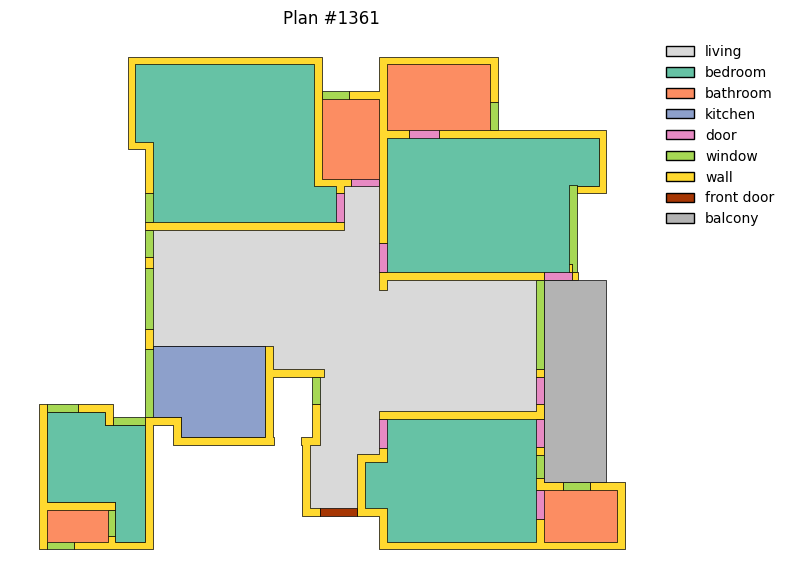

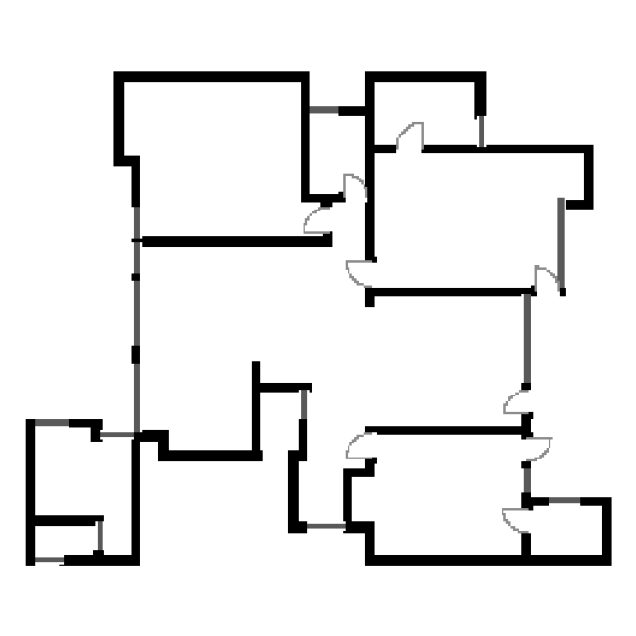

In [13]:
idx = random.randrange(len(plans))
plan = plans[idx]

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()

img = get_2d_plan(plan, shape=(256, 256), show=False)

img_big = cv2.resize(
    img,
    (512, 512),
    interpolation=cv2.INTER_NEAREST
)

plt.figure(figsize=(8, 8))
plt.imshow(img_big, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

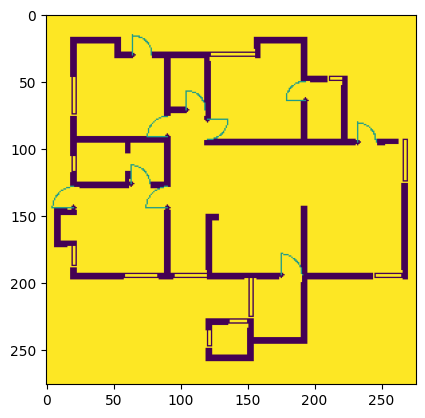

In [6]:
idx = random.randrange(len(plans))
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
# img_path = f'plans/plan_{idx}.png'
# cv2.imwrite(img_path, img)

plt.imshow(img)
plt.show()

Total components found (excl. background): 6
  [skip (outside)] comp 1: area=  26187, bbox=(226,2,288,91)
  [KEEP] comp 2: area=  58293, bbox=(7,38,206,283)
  [KEEP] comp 3: area=  92896, bbox=(226,106,284,373)
  [KEEP] comp 4: area=  11193, bbox=(7,334,126,89)
  [KEEP] comp 5: area=  12805, bbox=(146,334,144,89)
  [skip (outside)] comp 6: area=  22284, bbox=(2,436,288,78)
Detected 4 rooms
  Room  1: bbox=(7, 38, 206, 283), centroid=(109, 178), area=58293
  Room  2: bbox=(226, 106, 284, 373), centroid=(380, 277), area=92896
  Room  3: bbox=(7, 334, 126, 89), centroid=(69, 377), area=11193
  Room  4: bbox=(146, 334, 144, 89), centroid=(217, 377), area=12805


<<< Graph >>>
Nodes:
  1: [[7, 38], [7, 319], [210, 320], [212, 39]]
  2: [[227, 106], [226, 319], [305, 322], [305, 477], [509, 478], [509, 334], [457, 332], [509, 319], [509, 106]]
  3: [[7, 334], [7, 421], [132, 421], [131, 334]]
  4: [[146, 335], [146, 421], [289, 422], [289, 334]]
Edges:
  1 <-> 2
  1 <-> 3
  1 <-> 4
  2 <-> 4
  3 <-> 4


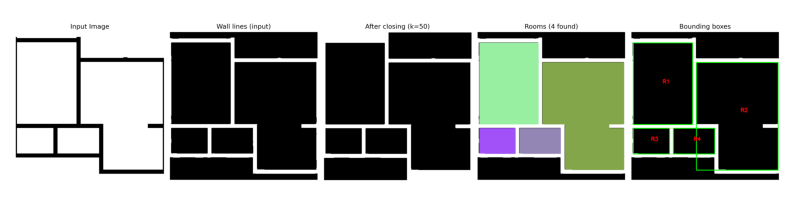

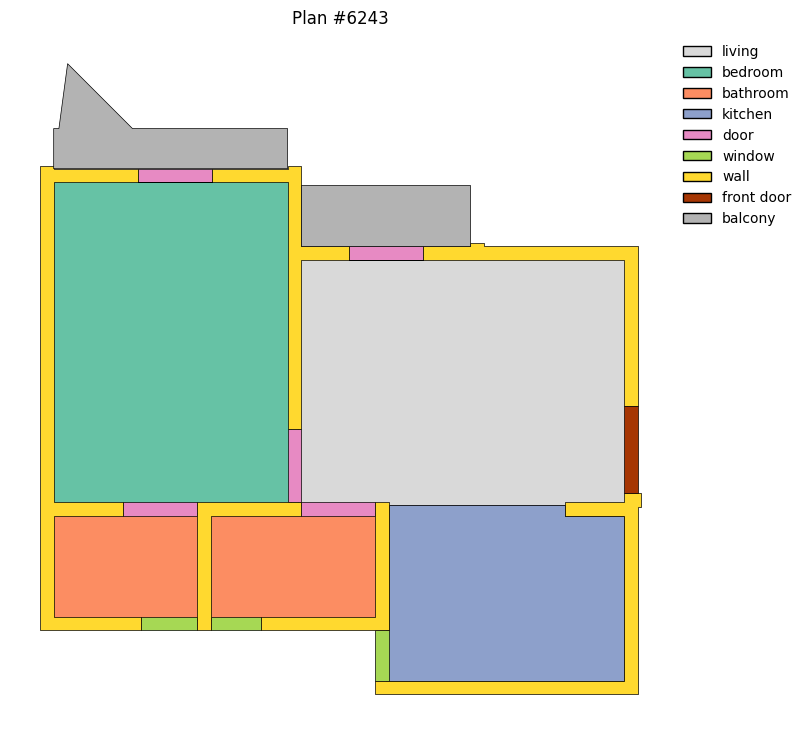

In [4]:
idx = random.randrange(len(plans))
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
img_path = f'plans/plan_{idx}.png'
cv2.imwrite(img_path, img)

from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries

build_graph(img_path, border=1, kernel_size=50, iterations=1)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 3
  [skip (area)] comp 1: area= 218310, bbox=(4,4,512,512)
  [KEEP] comp 2: area=   4074, bbox=(235,258,49,86)
  [KEEP] comp 3: area=  12592, bbox=(213,348,160,97)
Detected 2 rooms
  Room  1: bbox=(235, 258, 49, 86), centroid=(258, 301), area=4074
  Room  2: bbox=(213, 348, 160, 97), centroid=(289, 398), area=12592
<<< Graph >>>
Nodes:
  1: [[235, 258], [235, 343], [283, 343], [283, 286], [278, 285], [278, 258]]
  2: [[213, 355], [213, 408], [235, 409], [236, 444], [291, 444], [292, 418], [295, 443], [372, 440], [371, 378], [316, 376], [315, 355], [298, 355], [296, 348], [230, 348], [228, 355]]
Edges:
  1 <-> 2


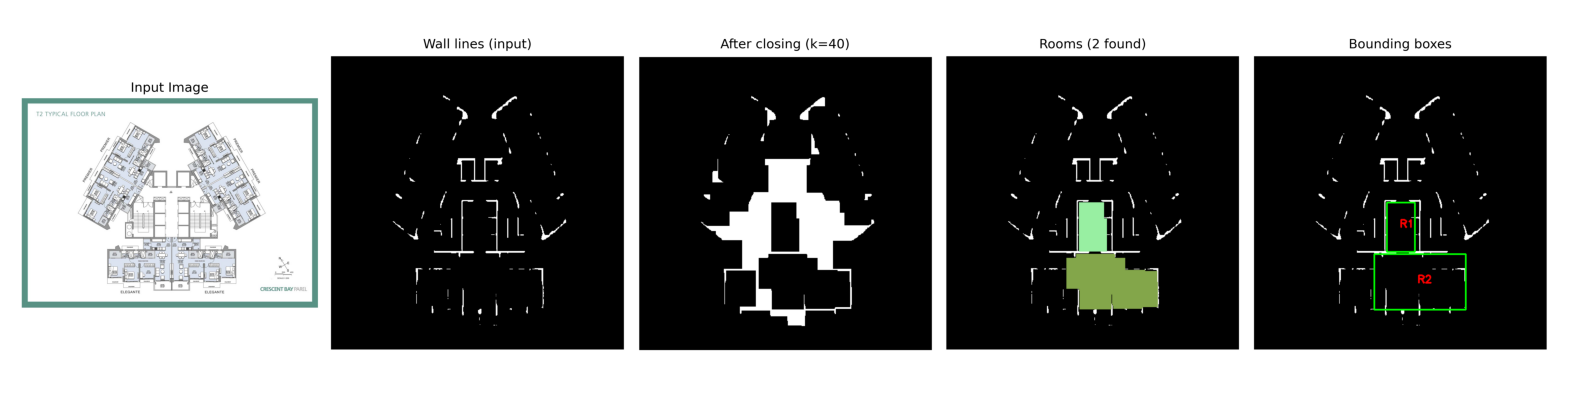

In [5]:
from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/page30_img17584.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page31_img17587.png"
# img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/clstr_aparna_2.png"
img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page14_img32.png"
# img_path = "test_images/test_image_2.png"

# build_graph(img_path, border=3, kernel_size=30, iterations=1, min_room_area = 10, max_room_area=50000)
build_graph(img_path, border=3, kernel_size=40, iterations=1, min_room_area = 10, max_room_area=50000)
# plot room_detection.png image
img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches
plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

/home/ubuntu/mitunet/graph_maker.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.weights_path, map_location=self.device)
libpng warning: iCCP: 

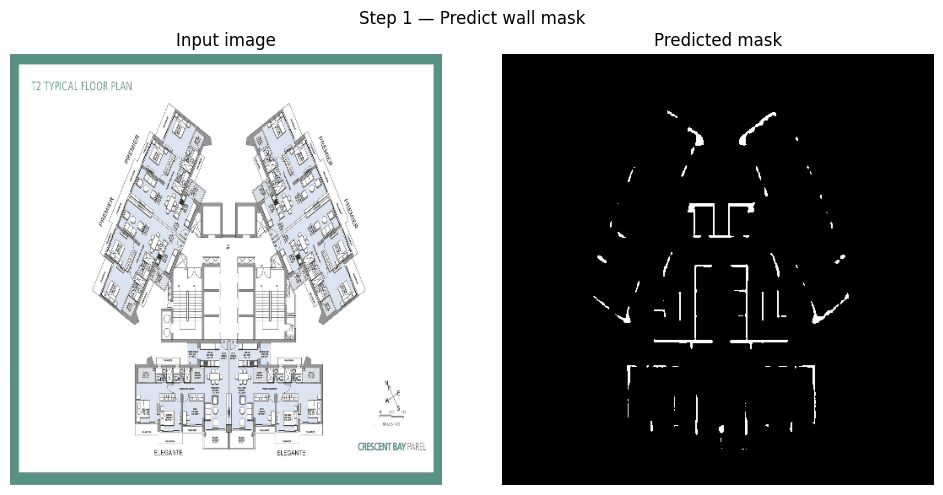

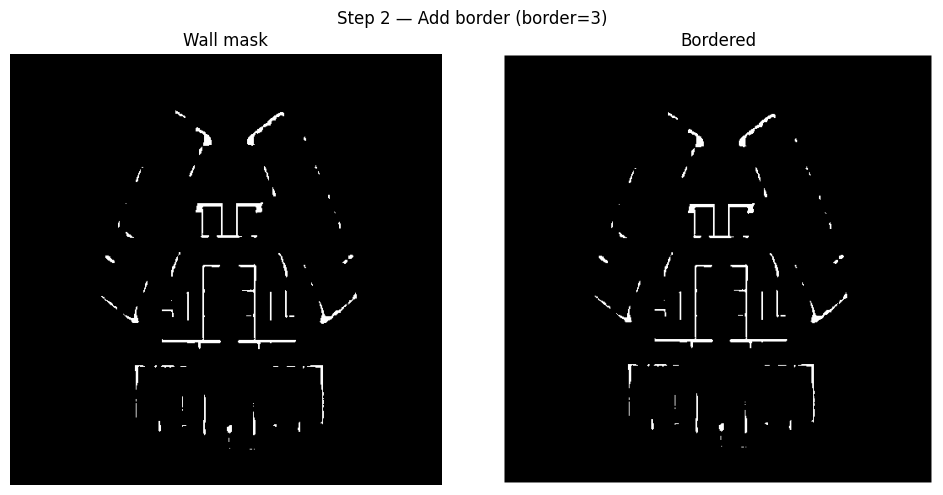

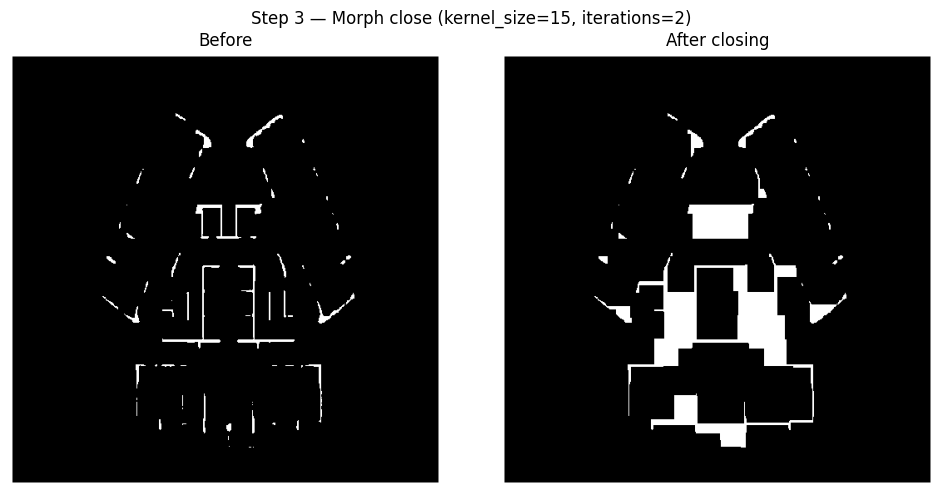

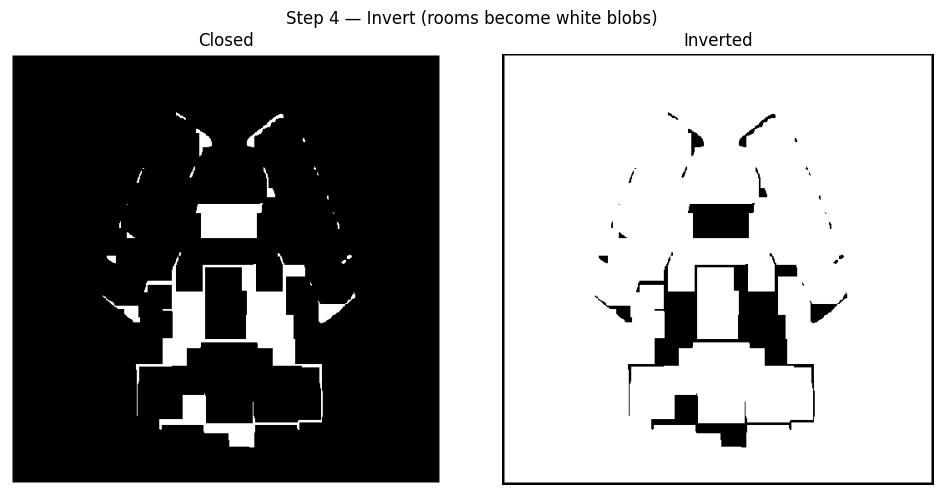

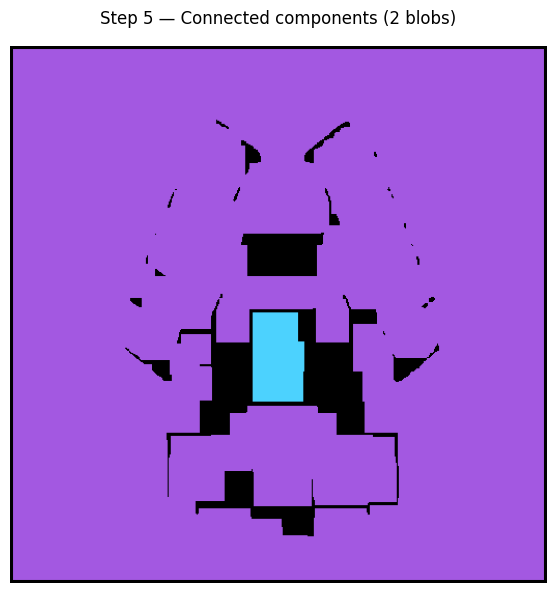

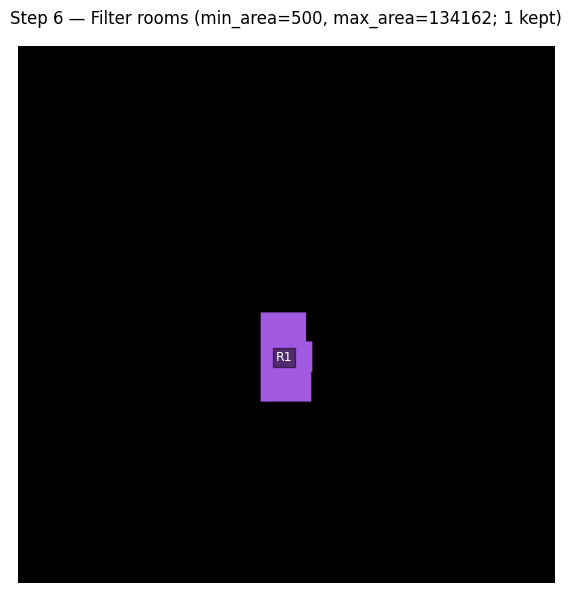

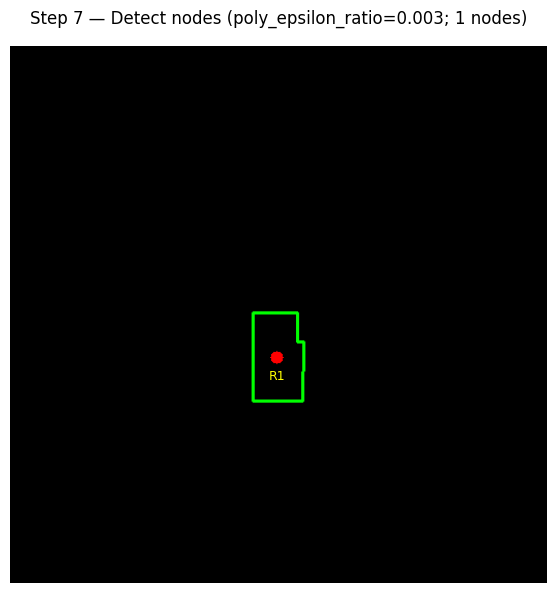

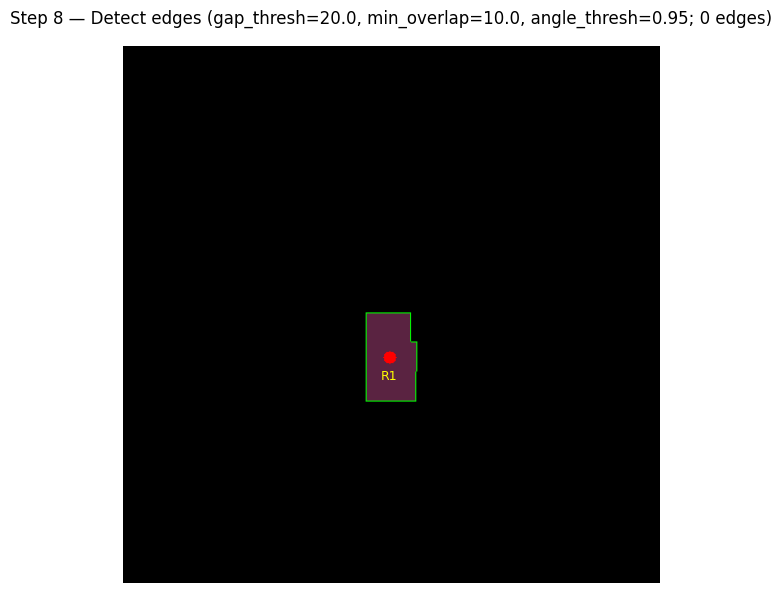

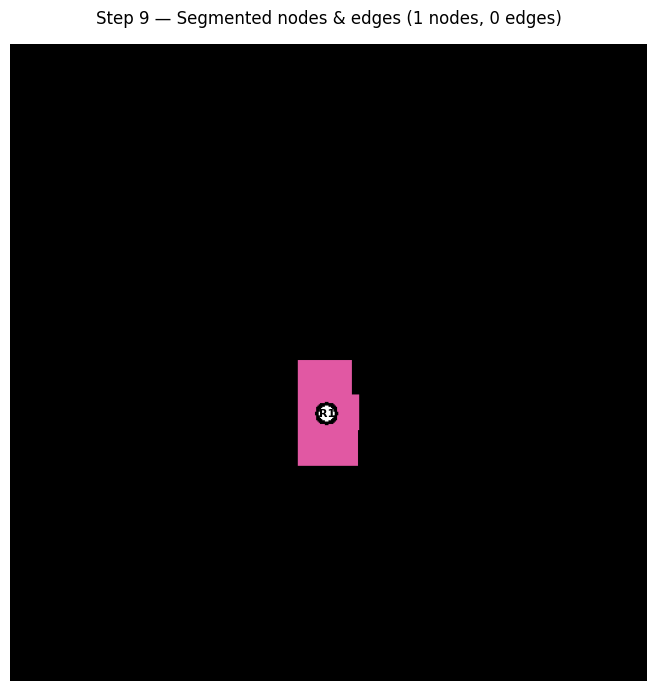

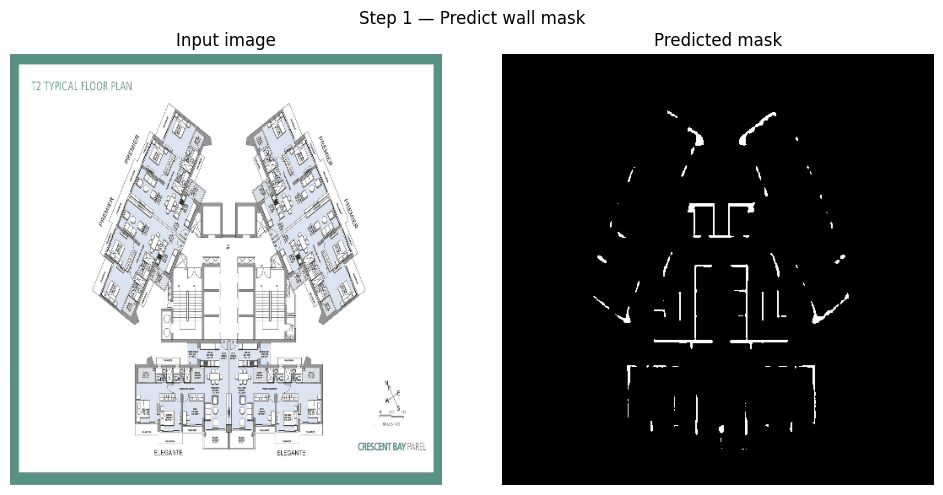

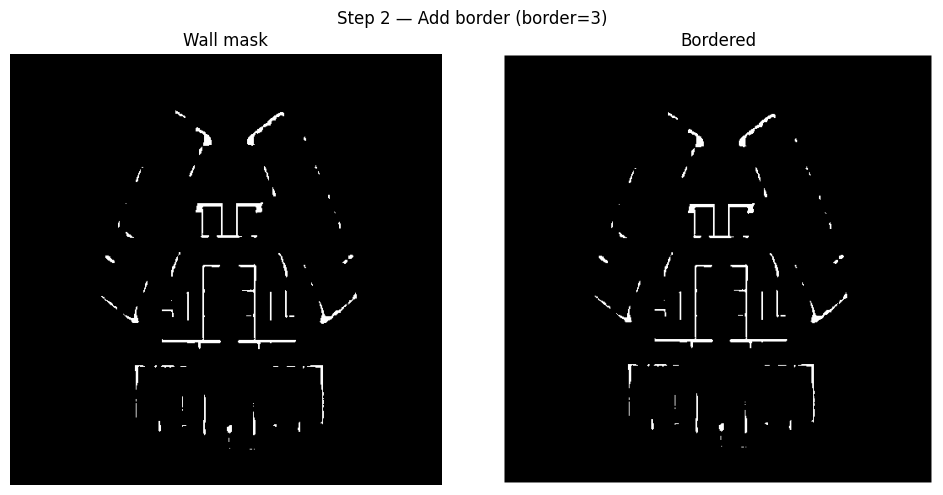

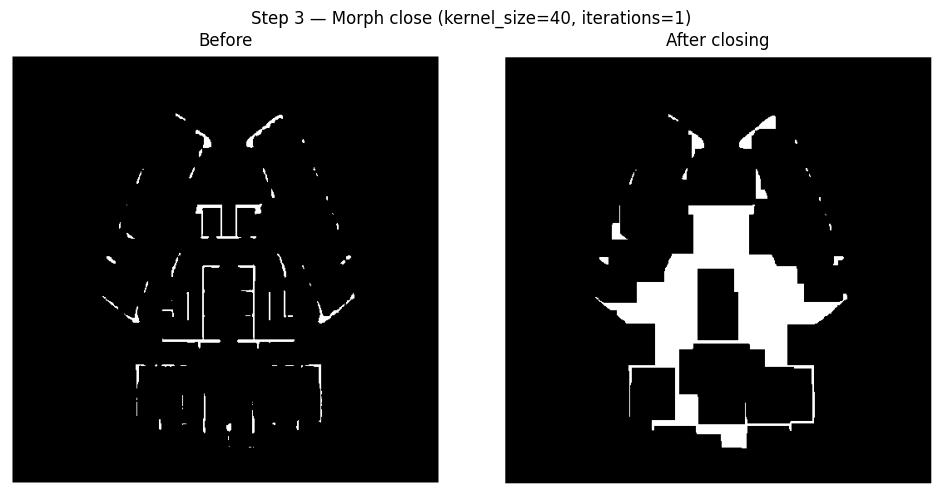

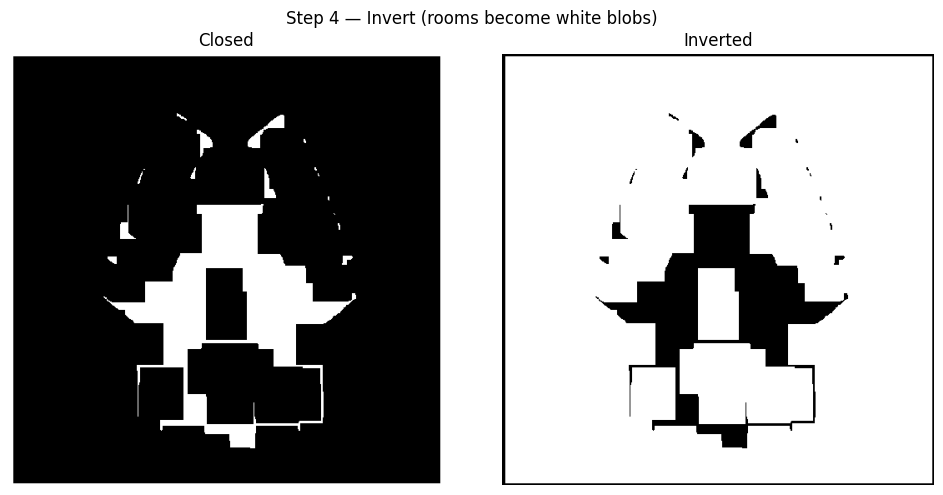

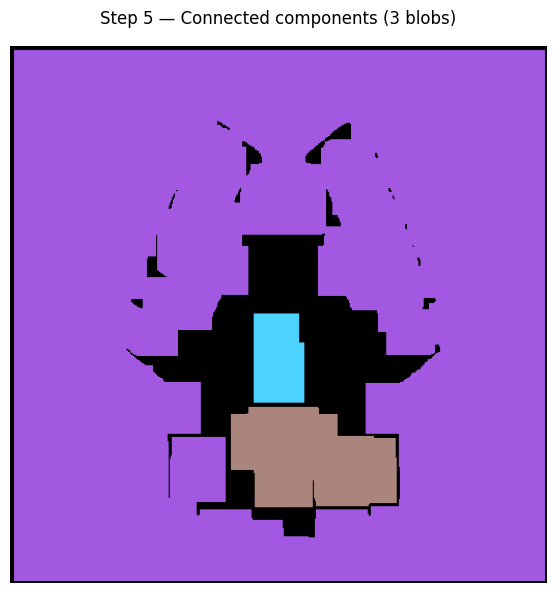

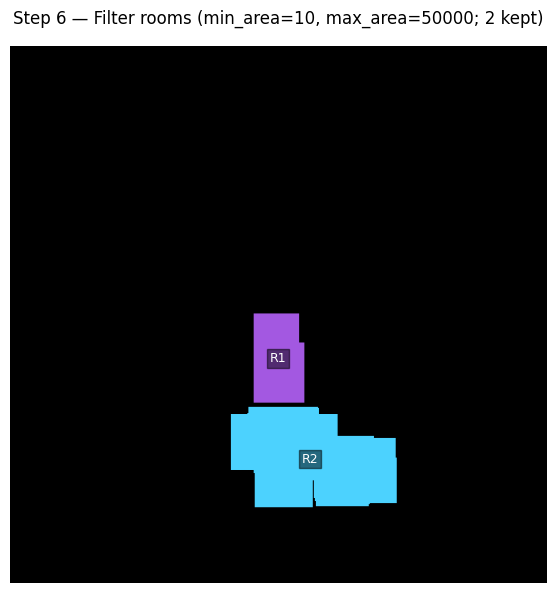

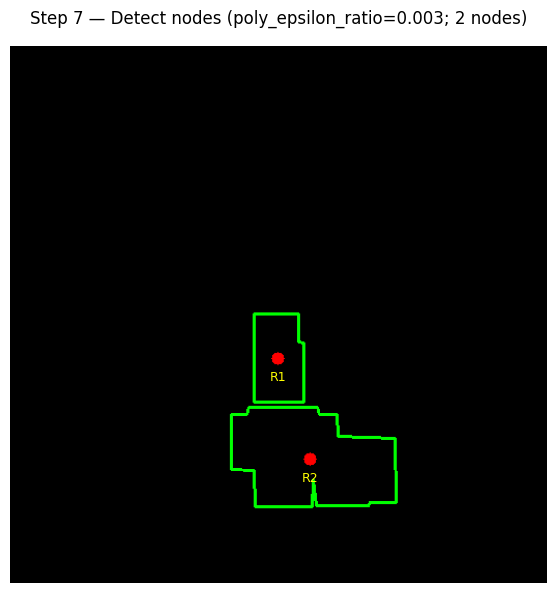

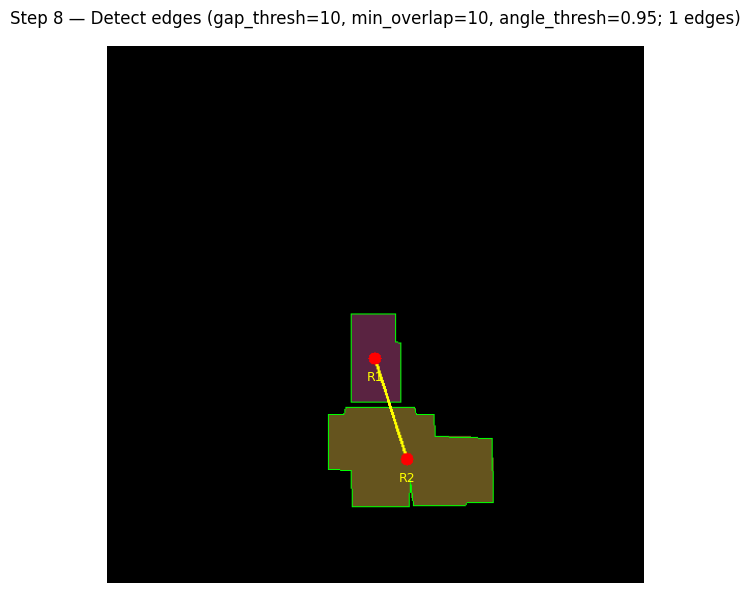

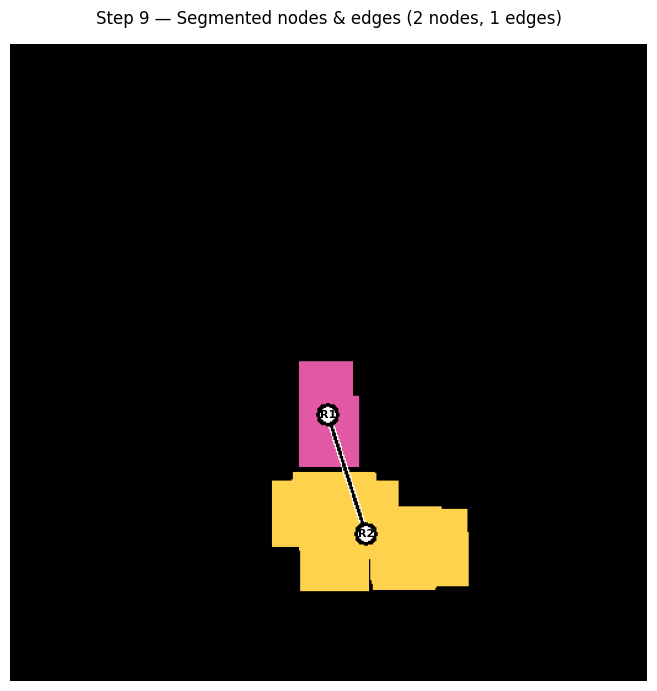

In [9]:
from graph_maker import GraphMaker
gm = GraphMaker(
    weights_path="/opt/dlami/nvme/mitunet_weights/mitunet.pth",
    device="cuda",
    input_size=512
)
img_path = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/page14_img32.png"
image = cv2.imread(img_path)
graph = gm.build_graph(
    image,
    show=True
)

graph = gm.build_graph(
        image,
        border=3,
        kernel_size=40,
        iterations=1,
        min_room_area=10,
        max_room_area=50000,
        poly_epsilon_ratio=0.003,
        gap_thresh=10,
        min_overlap=10,
        angle_thresh=0.95,
        show=True,
    )


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 33
  [skip (outside)] comp 1: area=   3600, bbox=(240,4,40,90)
  [KEEP] comp 2: area=  13125, bbox=(124,31,111,149)
  [KEEP] comp 3: area=   3019, bbox=(20,32,57,54)
  [KEEP] comp 4: area=   4283, bbox=(284,32,78,55)
  [KEEP] comp 5: area=   3980, bbox=(408,32,77,54)
  [KEEP] comp 6: area=   2080, bbox=(364,35,40,52)
  [skip (outside)] comp 7: area=   5530, bbox=(4,88,107,55)
  [KEEP] comp 8: area=   4651, bbox=(284,89,70,74)
  [KEEP] comp 9: area=   4037, bbox=(357,89,81,55)
  [KEEP] comp 10: area=   4697, bbox=(443,89,55,93)
  [KEEP] comp 11: area=   5923, bbox=(200,146,79,81)
  [KEEP] comp 12: area=   2351, bbox=(20,183,56,42)
  [KEEP] comp 13: area=   3124, bbox=(20,228,57,55)
  [KEEP] comp 14: area=  15994, bbox=(33,228,202,121)
  [KEEP] comp 15: area=   4276, bbox=(407,228,78,55)
  [KEEP] comp 16: area=   4249, bbox=(284,229,78,55)
  [KEEP] comp 17: area=   3769, bbox=(166,286,69,55)
  [KEEP] comp 18: area=   2956, bbox=(384,286,54,55)
 

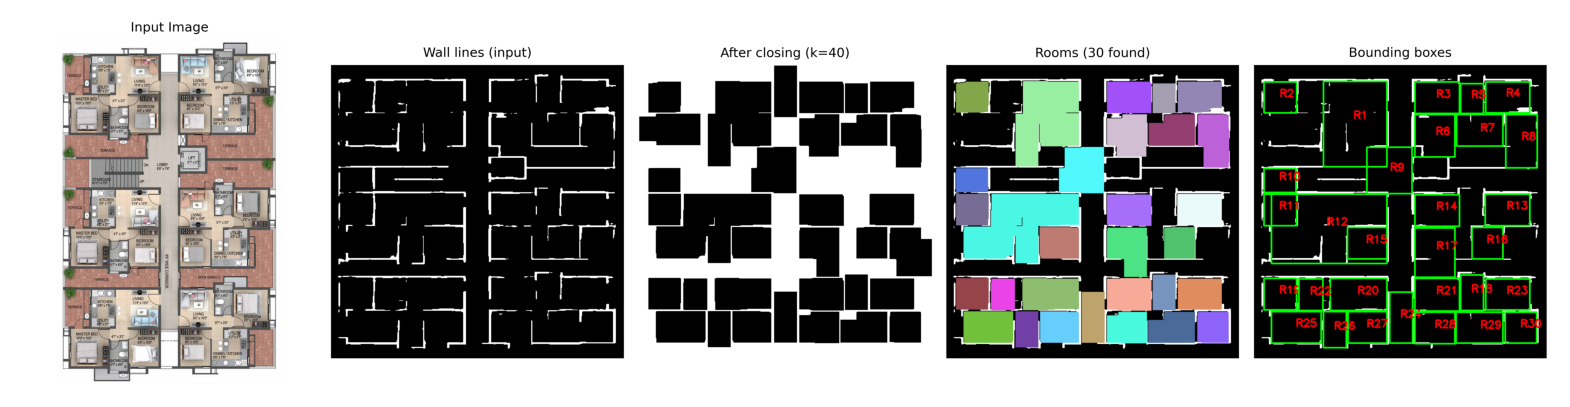

Total components found (excl. background): 6
  [skip (area)] comp 1: area= 198689, bbox=(4,4,512,512)
  [KEEP] comp 2: area=   2865, bbox=(272,169,48,60)
  [KEEP] comp 3: area=   2860, bbox=(185,277,51,59)
  [KEEP] comp 4: area=   3146, bbox=(237,327,48,68)
  [KEEP] comp 5: area=   4156, bbox=(446,348,56,77)
  [skip (outside)] comp 6: area=   3444, bbox=(467,444,49,72)
Detected 4 rooms
  Room  1: bbox=(272, 169, 48, 60), centroid=(295, 198), area=2865
  Room  2: bbox=(185, 277, 51, 59), centroid=(209, 306), area=2860
  Room  3: bbox=(237, 327, 48, 68), centroid=(260, 359), area=3146
  Room  4: bbox=(446, 348, 56, 77), centroid=(472, 384), area=4156
<<< Graph >>>
Nodes:
  1: [[272, 169], [272, 228], [314, 228], [319, 225], [319, 169]]
  2: [[185, 277], [188, 335], [235, 335], [235, 287], [225, 287], [224, 277]]
  3: [[237, 327], [237, 367], [241, 394], [280, 394], [284, 370], [284, 327]]
  4: [[446, 348], [446, 419], [456, 424], [495, 424], [501, 388], [501, 348]]
Edges:
  2 <-> 3


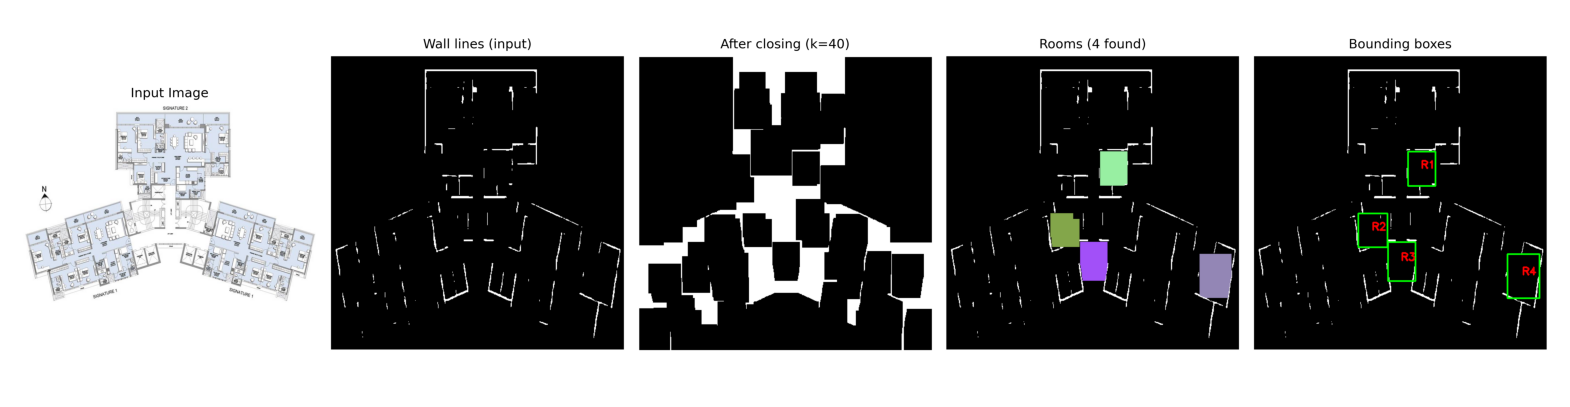

Total components found (excl. background): 4
  [skip (area)] comp 1: area= 224093, bbox=(4,4,512,512)
  [KEEP] comp 2: area=   3400, bbox=(234,268,60,60)
  [KEEP] comp 3: area=   1600, bbox=(191,284,40,40)
  [KEEP] comp 4: area=   1600, bbox=(297,284,40,40)
Detected 3 rooms
  Room  1: bbox=(234, 268, 60, 60), centroid=(263, 296), area=3400
  Room  2: bbox=(191, 284, 40, 40), centroid=(210, 303), area=1600
  Room  3: bbox=(297, 284, 40, 40), centroid=(316, 303), area=1600
<<< Graph >>>
Nodes:
  1: [[234, 268], [234, 307], [245, 327], [286, 327], [288, 316], [293, 314], [293, 268]]
  2: [[191, 284], [191, 323], [230, 323], [230, 284]]
  3: [[297, 284], [297, 323], [336, 323], [336, 284]]
Edges:
  1 <-> 2
  1 <-> 3


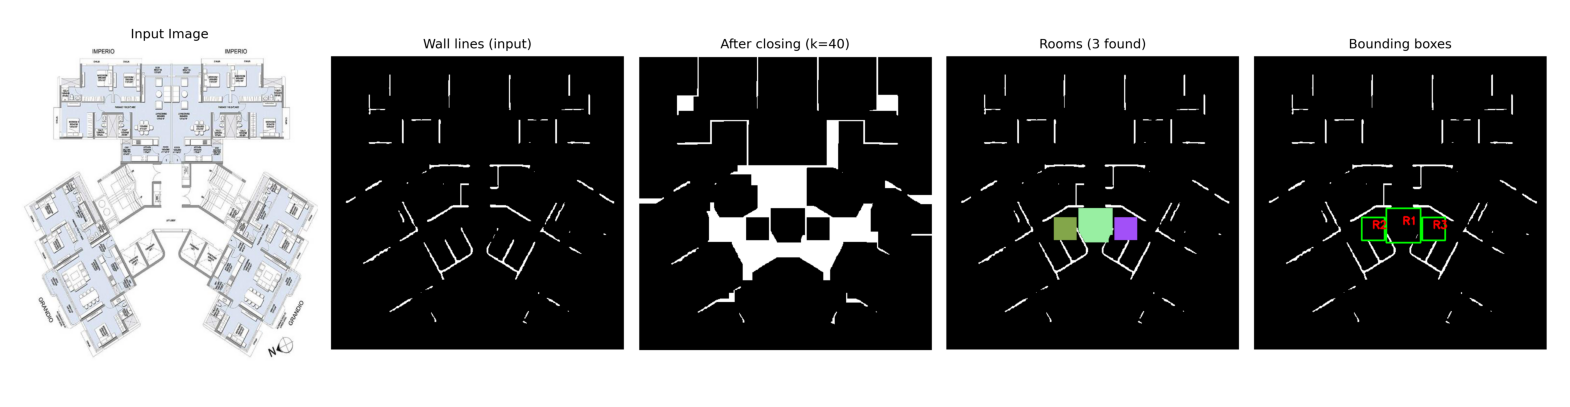

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 1
  [skip (area)] comp 1: area= 262069, bbox=(4,4,512,512)
Detected 0 rooms
<<< Graph >>>
Nodes:
Edges:


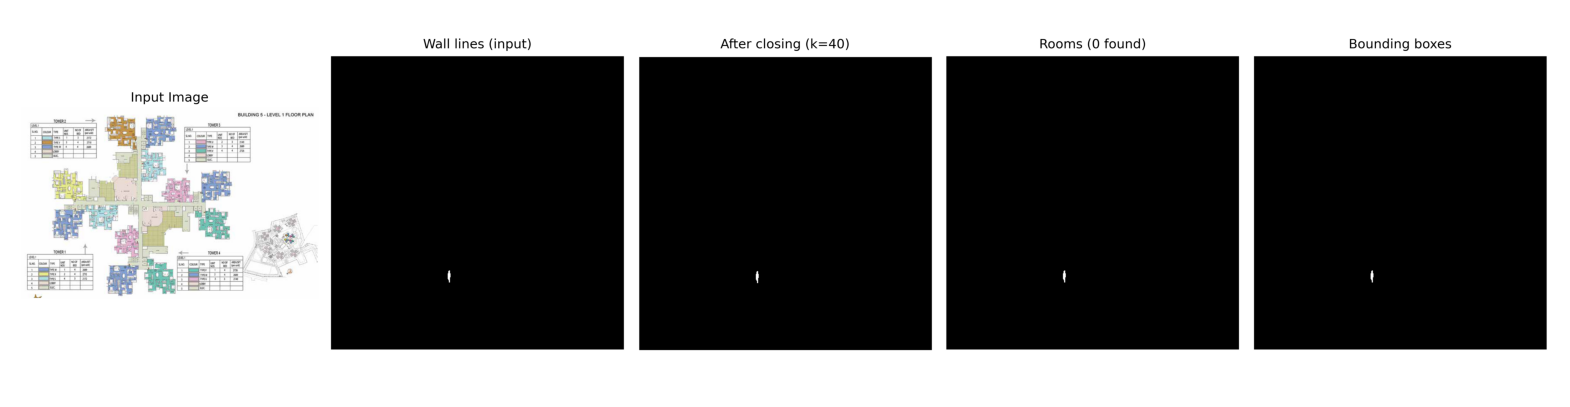

Total components found (excl. background): 1
  [skip (area)] comp 1: area= 255844, bbox=(4,4,512,512)
Detected 0 rooms
<<< Graph >>>
Nodes:
Edges:


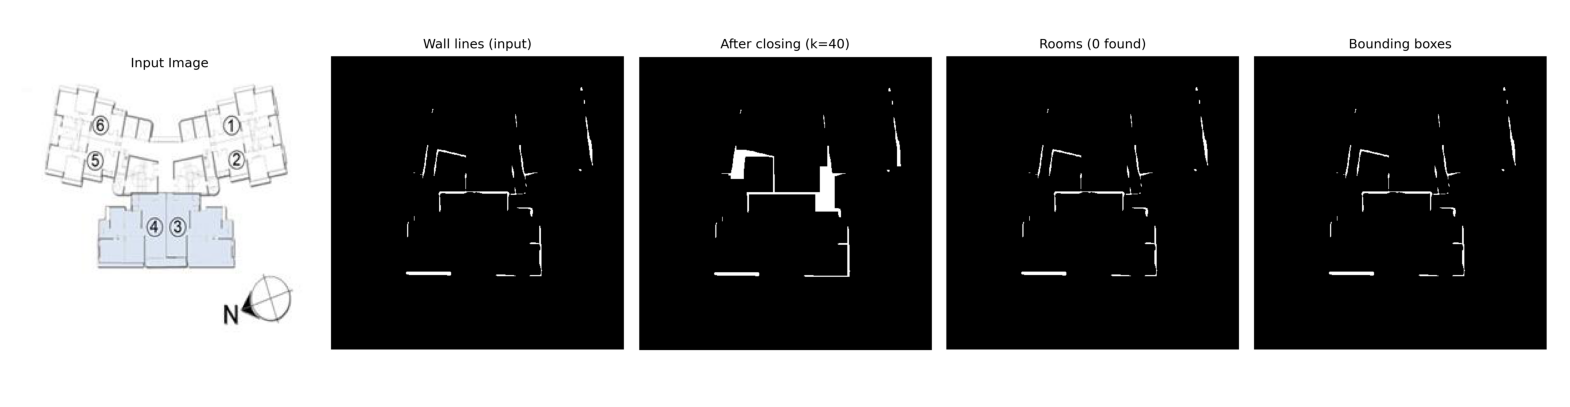

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 8
  [skip (area)] comp 1: area=  69474, bbox=(4,4,512,512)
  [skip (area)] comp 2: area=  78158, bbox=(101,4,415,248)
  [KEEP] comp 3: area=   5631, bbox=(56,136,78,90)
  [KEEP] comp 4: area=  43783, bbox=(49,199,388,231)
  [skip (outside)] comp 5: area=   6354, bbox=(398,256,118,59)
  [KEEP] comp 6: area=   2818, bbox=(438,335,42,68)
  [KEEP] comp 7: area=   2964, bbox=(49,384,52,57)
  [KEEP] comp 8: area=   2107, bbox=(109,407,49,43)
Detected 5 rooms
  Room  1: bbox=(56, 136, 78, 90), centroid=(100, 184), area=5631
  Room  2: bbox=(49, 199, 388, 231), centroid=(232, 319), area=43783
  Room  3: bbox=(438, 335, 42, 68), centroid=(458, 368), area=2818
  Room  4: bbox=(49, 384, 52, 57), centroid=(74, 412), area=2964
  Room  5: bbox=(109, 407, 49, 43), centroid=(133, 428), area=2107
<<< Graph >>>
Nodes:
  1: [[86, 136], [86, 173], [56, 176], [56, 217], [79, 217], [81, 225], [133, 225], [133, 136]]
  2: [[61, 230], [49, 358], [124, 379], [125, 339

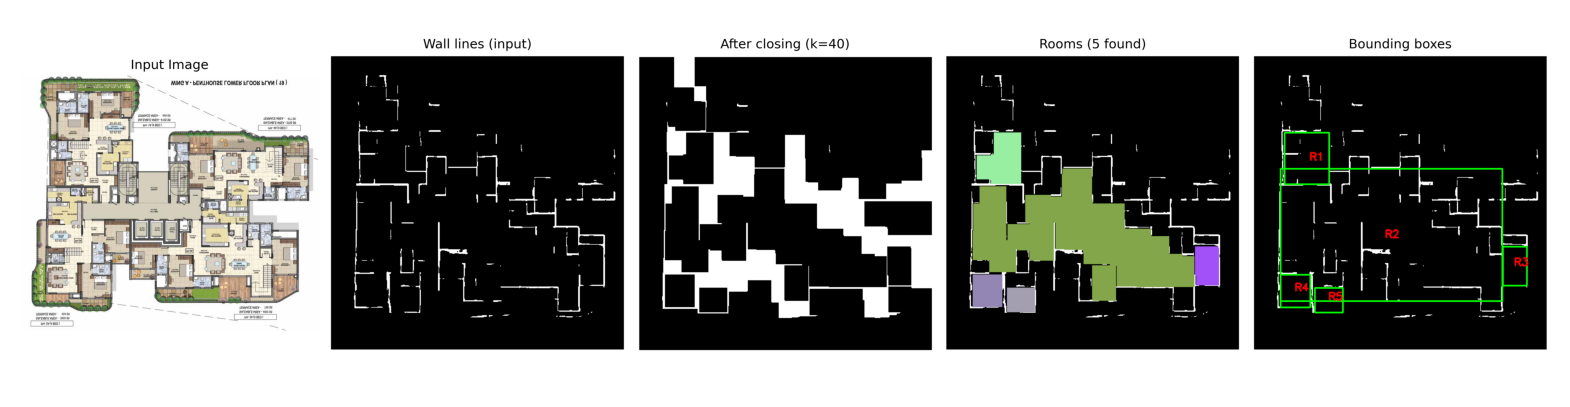

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 4
  [skip (area)] comp 1: area= 205534, bbox=(4,4,512,512)
  [KEEP] comp 2: area=   2828, bbox=(244,100,60,48)
  [KEEP] comp 3: area=   1760, bbox=(247,188,44,40)
  [KEEP] comp 4: area=   4199, bbox=(234,249,81,54)
Detected 3 rooms
  Room  1: bbox=(244, 100, 60, 48), centroid=(273, 123), area=2828
  Room  2: bbox=(247, 188, 44, 40), centroid=(268, 207), area=1760
  Room  3: bbox=(234, 249, 81, 54), centroid=(274, 276), area=4199
<<< Graph >>>
Nodes:
  1: [[245, 100], [244, 141], [248, 142], [248, 147], [299, 147], [299, 142], [303, 141], [302, 100]]
  2: [[247, 188], [247, 227], [290, 227], [290, 188]]
  3: [[234, 261], [235, 302], [314, 301], [314, 260], [307, 259], [307, 249], [242, 249], [242, 260]]
Edges:


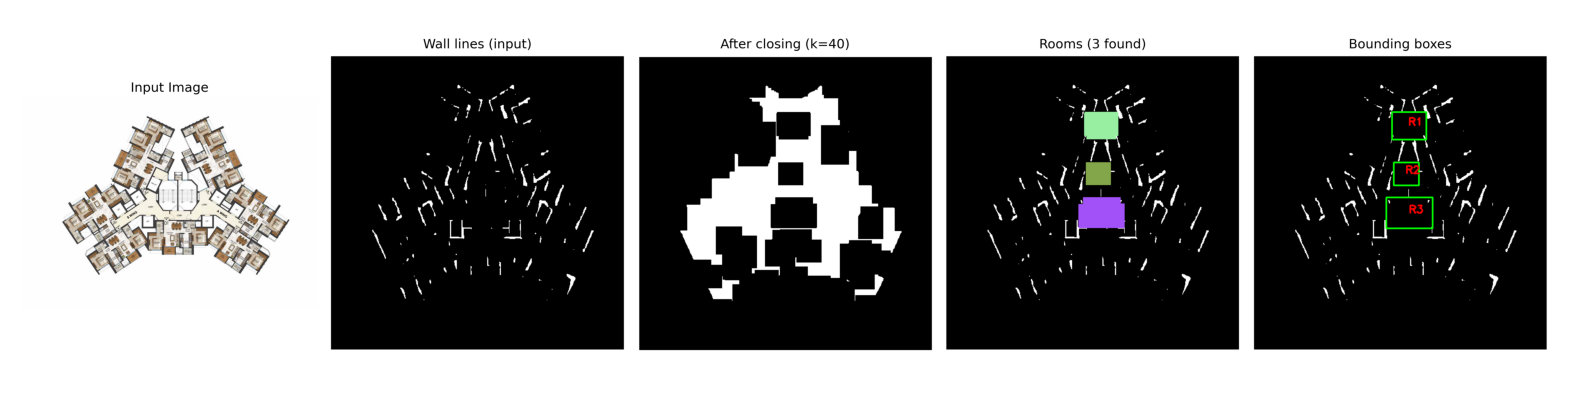

Total components found (excl. background): 12
  [skip (area)] comp 1: area= 110294, bbox=(4,4,512,283)
  [skip (outside)] comp 2: area=  11657, bbox=(4,256,151,137)
  [KEEP] comp 3: area=   1600, bbox=(400,256,40,40)
  [KEEP] comp 4: area=   2023, bbox=(191,264,46,44)
  [skip (outside)] comp 5: area=  11695, bbox=(395,295,121,125)
  [KEEP] comp 6: area=   6405, bbox=(238,296,88,102)
  [skip (outside)] comp 7: area=  13977, bbox=(118,328,119,188)
  [skip (outside)] comp 8: area=  10132, bbox=(335,352,99,164)
  [KEEP] comp 9: area=   2083, bbox=(39,395,41,51)
  [KEEP] comp 10: area=   4735, bbox=(238,400,81,72)
  [KEEP] comp 11: area=   1934, bbox=(192,460,45,43)
  [skip (outside)] comp 12: area=   1764, bbox=(4,474,42,42)
Detected 6 rooms
  Room  1: bbox=(400, 256, 40, 40), centroid=(419, 275), area=1600
  Room  2: bbox=(191, 264, 46, 44), centroid=(213, 285), area=2023
  Room  3: bbox=(238, 296, 88, 102), centroid=(278, 348), area=6405
  Room  4: bbox=(39, 395, 41, 51), centroid=(58, 4

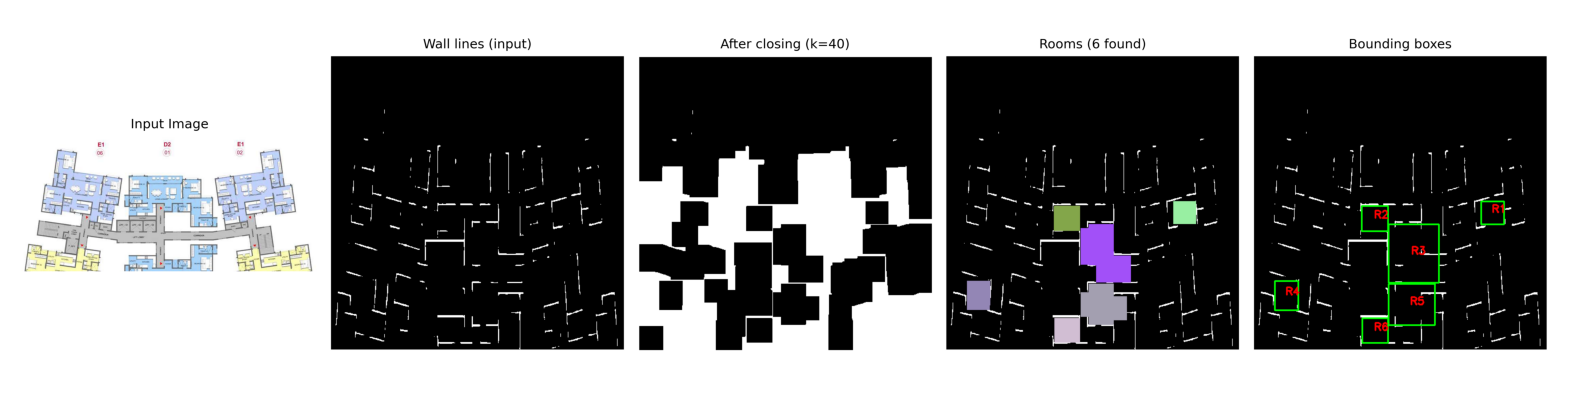

Total components found (excl. background): 3
  [skip (area)] comp 1: area= 234203, bbox=(4,4,512,512)
  [KEEP] comp 2: area=   3419, bbox=(144,197,60,57)
  [KEEP] comp 3: area=   3356, bbox=(261,308,48,70)
Detected 2 rooms
  Room  1: bbox=(144, 197, 60, 57), centroid=(173, 225), area=3419
  Room  2: bbox=(261, 308, 48, 70), centroid=(284, 342), area=3356
<<< Graph >>>
Nodes:
  1: [[144, 197], [144, 253], [203, 253], [202, 197]]
  2: [[261, 308], [261, 377], [308, 377], [307, 308]]
Edges:


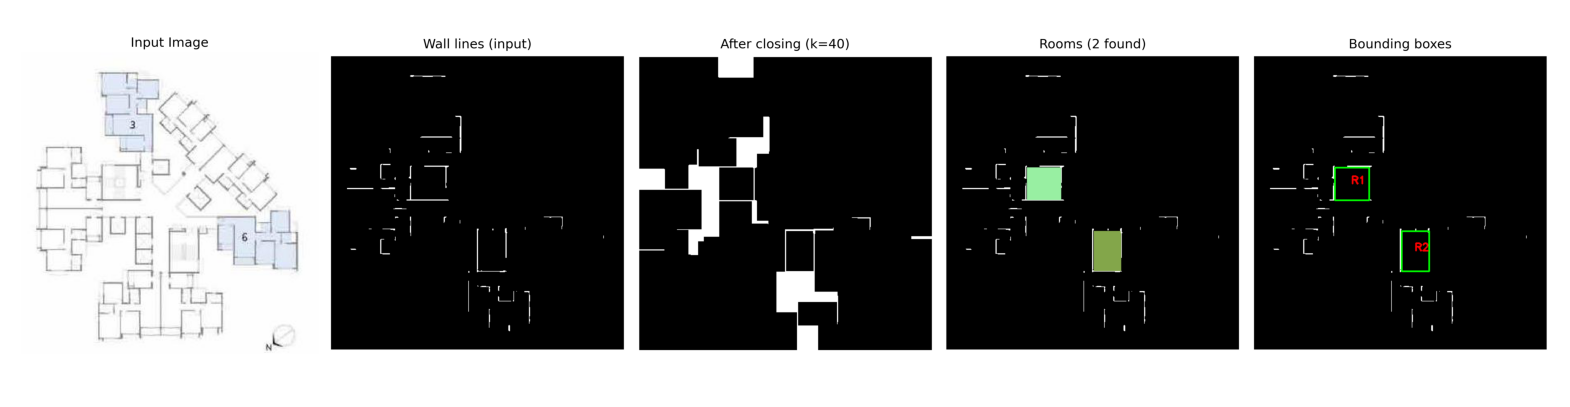

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total components found (excl. background): 7
  [skip (outside)] comp 1: area=  29738, bbox=(4,4,185,228)
  [skip (outside)] comp 2: area=  12298, bbox=(201,4,113,122)
  [skip (outside)] comp 3: area=  28835, bbox=(329,4,187,205)
  [KEEP] comp 4: area=   4892, bbox=(416,190,59,99)
  [skip (outside)] comp 5: area=  41245, bbox=(4,225,296,291)
  [skip (outside)] comp 6: area=  31898, bbox=(301,258,215,258)
  [KEEP] comp 7: area=   6716, bbox=(216,375,84,81)
Detected 2 rooms
  Room  1: bbox=(416, 190, 59, 99), centroid=(444, 237), area=4892
  Room  2: bbox=(216, 375, 84, 81), centroid=(257, 414), area=6716
<<< Graph >>>
Nodes:
  1: [[427, 190], [416, 197], [416, 258], [431, 259], [431, 288], [473, 287], [474, 247], [459, 246], [467, 237], [466, 190]]
  2: [[216, 375], [218, 455], [298, 454], [299, 375]]
Edges:


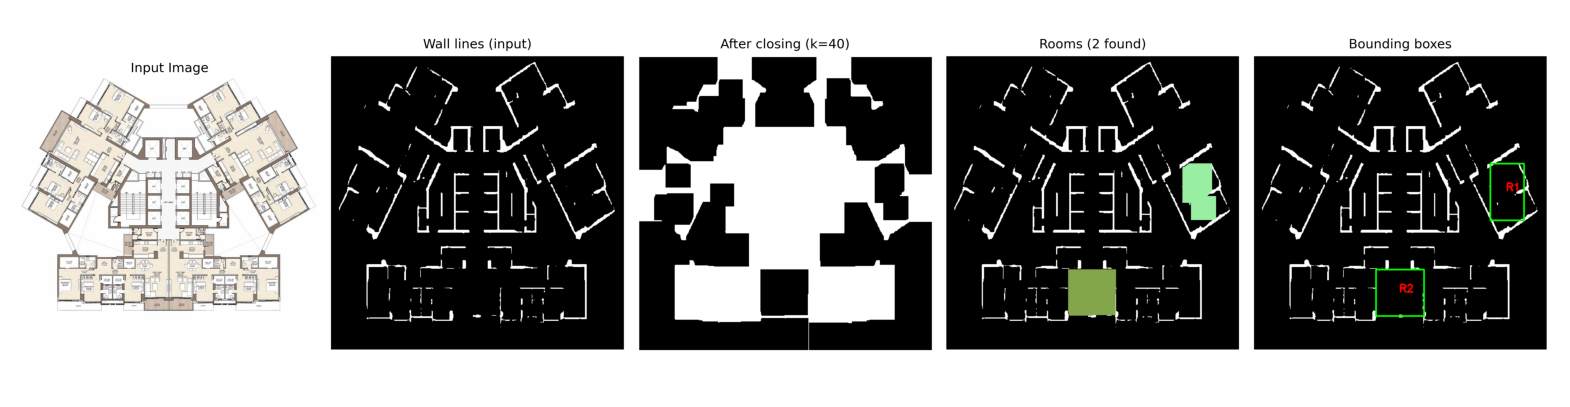

In [ ]:
from seg_graph_worker import build_graph, build_graph_from_mask, predict, find_room_boundaries
# from this path go through 10 images
plans_dir = "/opt/dlami/nvme/CPMS_ClusterPlans/plans/"

for img_name in os.listdir(plans_dir)[:10]:

    img_path = os.path.join(plans_dir, img_name)
    # build_graph(img_path, border=3, kernel_size=30, iterations=1, min_room_area = 10, max_room_area=50000)
    build_graph(img_path, border=3, kernel_size=40, iterations=1, min_room_area = 10, max_room_area=50000)
    # plot room_detection.png image
    img = cv2.imread('room_detection.png')
    # set fig size to 10x10 inches
    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [ ]:
def validate_graph(plan: Dict[str, Any],
                   rooms: List[Dict],
                   pred_graph: Dict,
                   shape: Tuple[int, int] = (512, 512),
                   iou_threshold: float = 0.5) -> Dict[str, Any]:
    """
    Validate predicted rooms/graph against ground-truth plan.

    Args:
        plan          : resplan plan dict (shapely geometries)
        rooms         : room list — MUST be from the same find_room_boundaries
                        call that produced pred_graph (same border/kernel params)
        pred_graph    : graph dict from build_graph_from_mask()
        shape         : canvas size the prediction was done at (H, W) = (512,512)
        iou_threshold : min IoU to count as TP
    """
    from scipy.optimize import linear_sum_assignment

    H, W = shape
    plan = normalize_keys(plan)

    # ── 1. GT nodes ───────────────────────────────────────────────────────────
    gt_graph  = plan_to_graph(plan)
    room_cats = {"living", "bedroom", "bathroom", "kitchen", "balcony"}
    gt_nodes  = [(nid, d) for nid, d in gt_graph.nodes(data=True)
                 if d.get("type") in room_cats]

    if not gt_nodes or not rooms:
        return {"error": "No GT nodes or predicted rooms to compare."}

    # ── 2. Build the same coordinate transform that the prediction pipeline uses
    #
    #   get_2d_plan does:
    #     geometry_to_mask(geom, shape=DEFAULT_CANVAS_SIZE)
    #     → np.flipud                    ← user added this
    #     → crop to non-background bbox  ← if user added the crop fix
    #     → saved to disk
    #   model then does A.Resize(512, 512)
    #
    #   We replicate the exact same steps for every GT room mask.
    # ─────────────────────────────────────────────────────────────────────────

    src = DEFAULT_CANVAS_SIZE          # (256, 256) — same shape used in get_2d_plan

    # Run get_2d_plan once (walls only) to detect crop bounds
    plan_render = get_2d_plan(plan, shape=src, show=False)   # has flipud inside
    bg = 255
    ys, xs = np.where(plan_render != bg)
    if len(ys) and len(xs):
        cy1, cy2 = int(ys.min()), int(ys.max()) + 1
        cx1, cx2 = int(xs.min()), int(xs.max()) + 1
    else:                              # no crop — use full canvas
        cy1, cy2 = 0, src[0]
        cx1, cx2 = 0, src[1]

    def _gt_mask(geom) -> np.ndarray:
        """Rasterise one GT room with the exact same transform as get_2d_plan."""
        mask = geometry_to_mask(geom, shape=src)   # raw plan coords → canvas
        mask = np.flipud(mask)                     # match get_2d_plan's flipud
        mask = mask[cy1:cy2, cx1:cx2]              # same crop
        mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
        return (mask > 0).astype(np.uint8) * 255

    # ── 3. Rasterise GT rooms ─────────────────────────────────────────────────
    gt_masks, gt_nids, gt_types = [], [], []
    for nid, d in gt_nodes:
        geom = d["geometry"]
        if geom is None or geom.is_empty:
            continue
        gt_masks.append(_gt_mask(geom))
        gt_nids.append(nid)
        gt_types.append(d["type"])
    
    # ── 4. Rasterise predicted rooms ──────────────────────────────────────────
    pred_masks = []
    for r in rooms:
        m = np.zeros((H, W), dtype=np.uint8)
        if r["contour"] is not None:
            cv2.fillPoly(m, [r["contour"]], 255)
        pred_masks.append(m)

    # ── 5. IoU matrix ─────────────────────────────────────────────────────────
    n_gt, n_pred = len(gt_masks), len(pred_masks)
    iou_mat = np.zeros((n_gt, n_pred), dtype=float)
    for i, gm in enumerate(gt_masks):
        for j, pm in enumerate(pred_masks):
            inter = np.logical_and(gm > 0, pm > 0).sum()
            union = np.logical_or(gm > 0, pm > 0).sum()
            iou_mat[i, j] = inter / union if union > 0 else 0.0

    print("IoU matrix (GT rows × Pred cols):\n", np.round(iou_mat, 2))

    # ── 6. Hungarian matching ─────────────────────────────────────────────────
    row_ind, col_ind = linear_sum_assignment(-iou_mat)
    matches = [(r, c, iou_mat[r, c])
               for r, c in zip(row_ind, col_ind)
               if iou_mat[r, c] >= iou_threshold]

    n_tp = len(matches)
    n_fp = n_pred - n_tp
    n_fn = n_gt   - n_tp
    prec = n_tp / (n_tp + n_fp) if (n_tp + n_fp) > 0 else 0.0
    rec  = n_tp / (n_tp + n_fn) if (n_tp + n_fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    miou = float(np.mean([m[2] for m in matches])) if matches else 0.0

    # ── 7. Edge validation ────────────────────────────────────────────────────
    gt_idx_to_pred   = {r: rooms[c]["id"] for r, c, _ in matches}
    matched_pred_ids = set(gt_idx_to_pred.values())

    gt_edge_set = set()
    for u, v in gt_graph.edges():
        if u in gt_nids and v in gt_nids:
            ui, vi = gt_nids.index(u), gt_nids.index(v)
            if ui in gt_idx_to_pred and vi in gt_idx_to_pred:
                a, b = gt_idx_to_pred[ui], gt_idx_to_pred[vi]
                gt_edge_set.add((min(a, b), max(a, b)))

    pred_edge_set = {(min(a, b), max(a, b))
                     for a, b in pred_graph["edges"]
                     if a in matched_pred_ids and b in matched_pred_ids}

    tp_e = len(gt_edge_set & pred_edge_set)
    fp_e = len(pred_edge_set - gt_edge_set)
    fn_e = len(gt_edge_set   - pred_edge_set)
    ep   = tp_e / (tp_e + fp_e) if (tp_e + fp_e) > 0 else 0.0
    er   = tp_e / (tp_e + fn_e) if (tp_e + fn_e) > 0 else 0.0
    ef   = 2 * ep * er / (ep + er) if (ep + er) > 0 else 0.0

    return {
        "room_tp":        n_tp,  "room_fp":  n_fp,  "room_fn":  n_fn,
        "room_precision": round(prec, 4),
        "room_recall":    round(rec,  4),
        "room_f1":        round(f1,   4),
        "mean_iou":       round(miou, 4),
        "edge_tp":        tp_e,  "edge_fp":  fp_e,  "edge_fn":  fn_e,
        "edge_precision": round(ep, 4),
        "edge_recall":    round(er, 4),
        "edge_f1":        round(ef, 4),
        "matches":        [(gt_nids[r], rooms[c]["id"], round(iou, 4))
                           for r, c, iou in matches],
    }

Total components found (excl. background): 10
  [skip (outside)] comp 1: area=  27265, bbox=(4,4,206,224)
  [skip (outside)] comp 2: area=  12640, bbox=(358,4,158,80)
  [KEEP] comp 3: area=  16640, bbox=(220,40,128,130)
  [skip (area)] comp 4: area=  69224, bbox=(88,94,428,230)
  [KEEP] comp 5: area=   8618, bbox=(6,238,133,65)
  [skip (outside)] comp 6: area=  23615, bbox=(420,270,96,246)
  [KEEP] comp 7: area=  25794, bbox=(34,312,153,169)
  [KEEP] comp 8: area=  24166, bbox=(264,316,147,165)
  [KEEP] comp 9: area=   6186, bbox=(196,334,59,105)
  [skip (outside)] comp 10: area=   4011, bbox=(196,448,59,68)
Detected 5 rooms
  Room  1: bbox=(220, 40, 128, 130), centroid=(283, 104), area=16640
  Room  2: bbox=(6, 238, 133, 65), centroid=(71, 269), area=8618
  Room  3: bbox=(34, 312, 153, 169), centroid=(110, 395), area=25794
  Room  4: bbox=(264, 316, 147, 165), centroid=(336, 397), area=24166
  Room  5: bbox=(196, 334, 59, 105), centroid=(224, 385), area=6186
<<< Graph >>>
Nodes:
  1: 

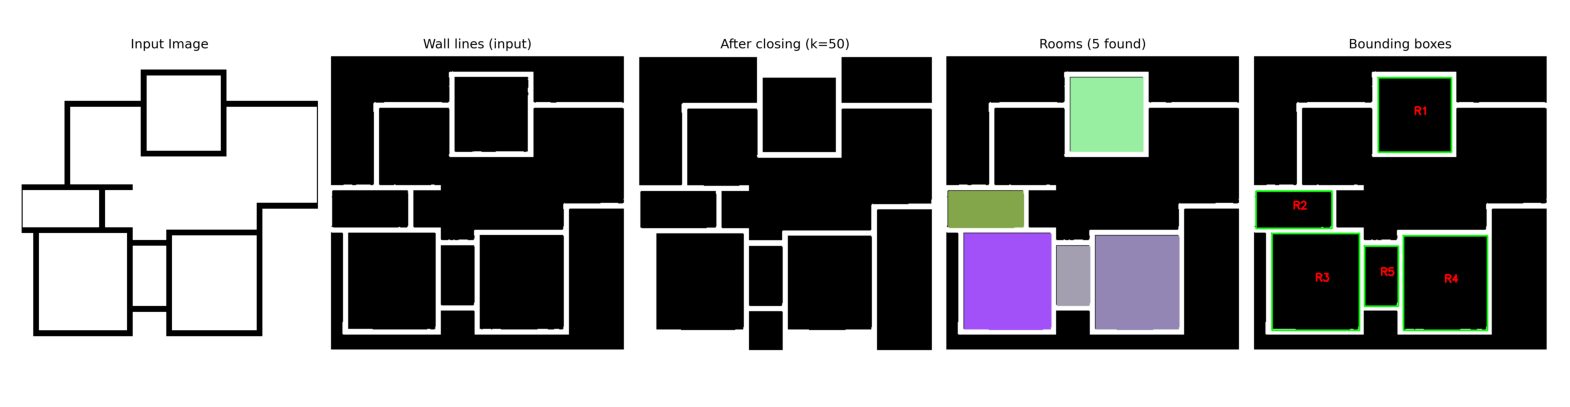

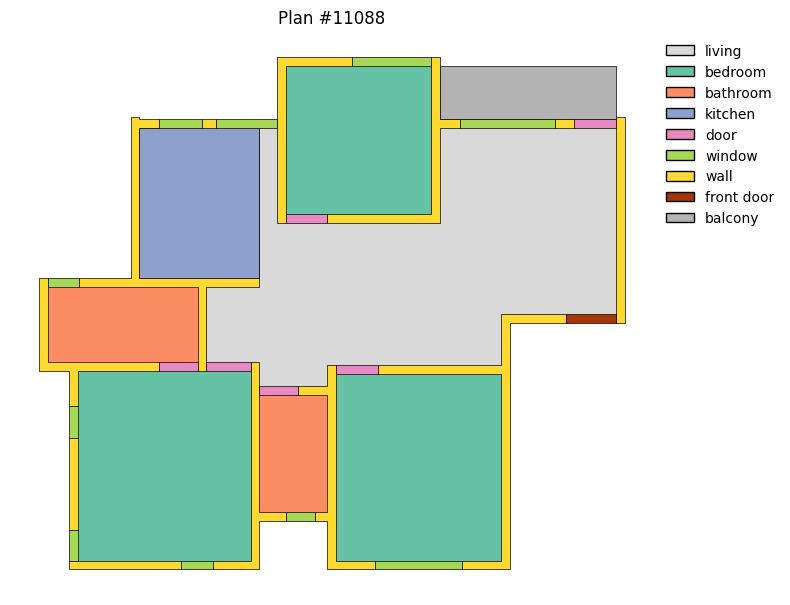

In [ ]:
idx = 11088
plan = plans[idx]

SHAPE = (512, 512)

img = get_2d_plan(plan, show=False)
img_path = f'plans/plan_{idx}.png'
cv2.imwrite(img_path, img)

# pred_graph = build_graph(img_path)   # your existing function
pred_graph = build_graph(img_path, border=3, kernel_size=50, iterations=1, min_room_area = 10, max_room_area=50000)

img = cv2.imread('room_detection.png')
# set fig size to 10x10 inches

pred_wall = predict(img_path, show=False)  # your existing function
rooms      = find_room_boundaries(img_path, pred_wall, border=3, kernel_size=50, iterations=1, min_room_area=10, max_room_area=50000)  # already returns rooms
metrics    = validate_graph(plan, rooms, pred_graph, shape=(512, 512))
print(metrics)

plt.figure(figsize=(20, 20))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# plot the original plot_plan
ax = plot_plan(plan, title=f'Plan #{idx}')
plt.show()

Total components found (excl. background): 8
  [skip (outside)] comp 1: area=  95880, bbox=(4,4,512,270)
  [KEEP] comp 2: area=  16894, bbox=(260,132,119,142)
  [KEEP] comp 3: area=  34243, bbox=(6,166,202,246)
  [KEEP] comp 4: area=  10038, bbox=(158,166,93,108)
  [KEEP] comp 5: area=  18791, bbox=(304,282,145,130)
  [skip (outside)] comp 6: area=   4632, bbox=(458,282,58,80)
  [KEEP] comp 7: area=   4367, bbox=(218,324,78,56)
  [skip (outside)] comp 8: area=  51492, bbox=(4,390,512,126)
Detected 5 rooms
  Room  1: bbox=(260, 132, 119, 142), centroid=(318, 202), area=16894
  Room  2: bbox=(6, 166, 202, 246), centroid=(108, 317), area=34243
  Room  3: bbox=(158, 166, 93, 108), centroid=(203, 219), area=10038
  Room  4: bbox=(304, 282, 145, 130), centroid=(375, 346), area=18791
  Room  5: bbox=(218, 324, 78, 56), centroid=(256, 351), area=4367
<<< Graph >>>
Nodes:
  1: [[260, 132], [260, 273], [377, 273], [378, 132]]
  2: [[83, 166], [82, 281], [7, 283], [7, 411], [207, 411], [207, 282]

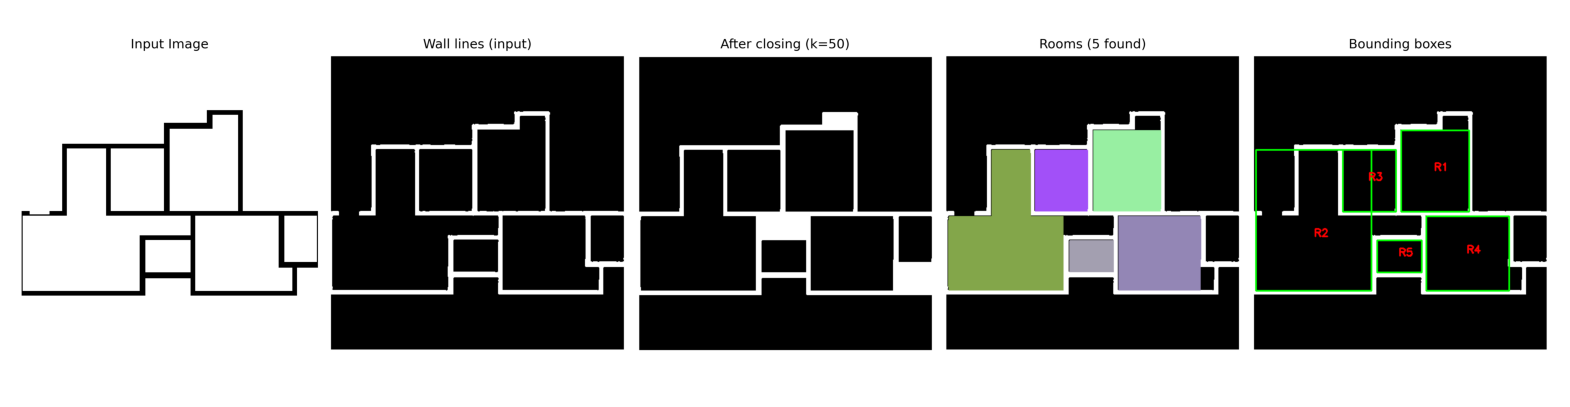

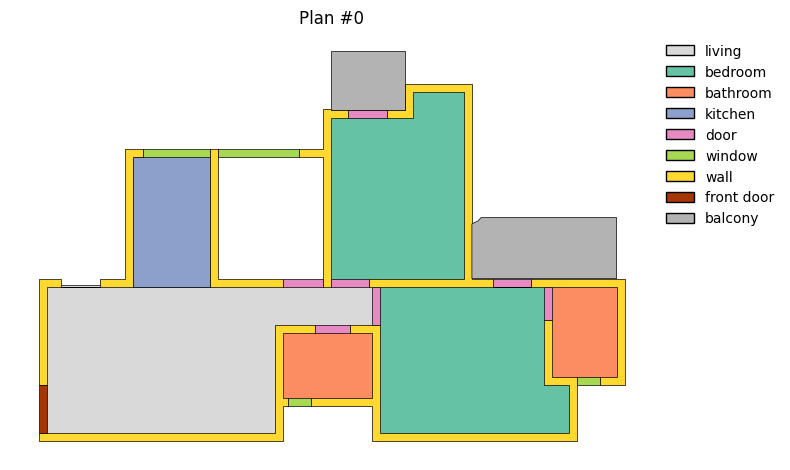

Total components found (excl. background): 10
  [skip (outside)] comp 1: area=  10399, bbox=(356,4,160,65)
  [skip (outside)] comp 2: area=  34385, bbox=(4,28,181,191)
  [KEEP] comp 3: area=  22198, bbox=(196,28,149,149)
  [skip (outside)] comp 4: area=  69281, bbox=(154,80,362,291)
  [skip (outside)] comp 5: area=   9477, bbox=(4,228,120,79)
  [skip (outside)] comp 6: area=  17360, bbox=(4,316,139,125)
  [skip (outside)] comp 7: area=  29137, bbox=(316,338,200,155)
  [KEEP] comp 8: area=   7871, bbox=(154,382,71,111)
  [KEEP] comp 9: area=   7869, bbox=(234,382,71,111)
  [skip (outside)] comp 10: area=   8895, bbox=(4,452,139,64)
Detected 3 rooms
  Room  1: bbox=(196, 28, 149, 149), centroid=(269, 101), area=22198
  Room  2: bbox=(154, 382, 71, 111), centroid=(188, 436), area=7871
  Room  3: bbox=(234, 382, 71, 111), centroid=(268, 437), area=7869
<<< Graph >>>
Nodes:
  1: [[196, 28], [196, 175], [343, 176], [344, 29]]
  2: [[155, 382], [154, 491], [223, 492], [223, 382]]
  3: [[235, 

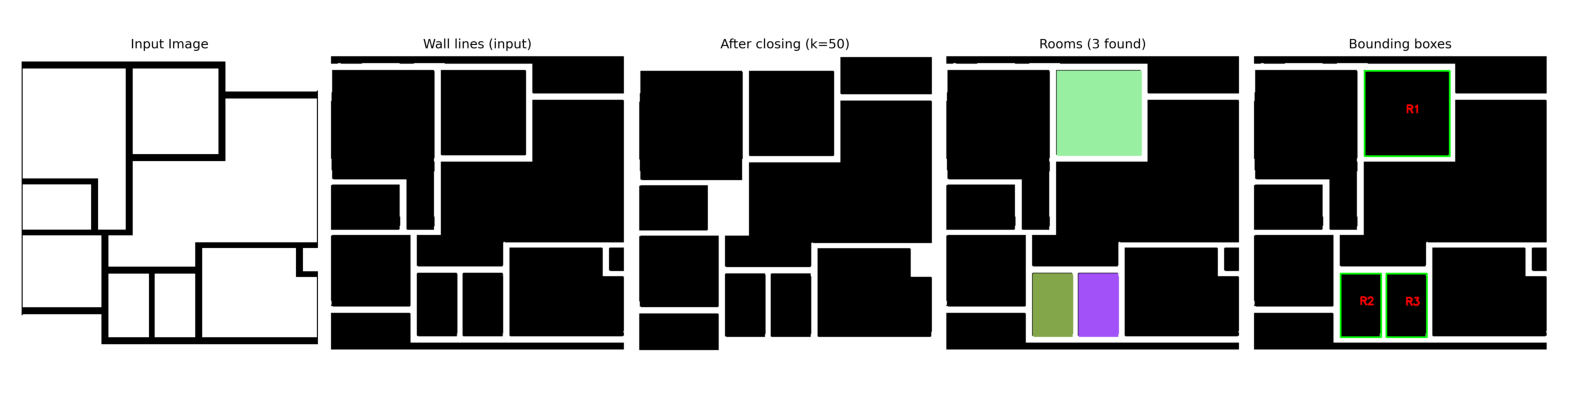

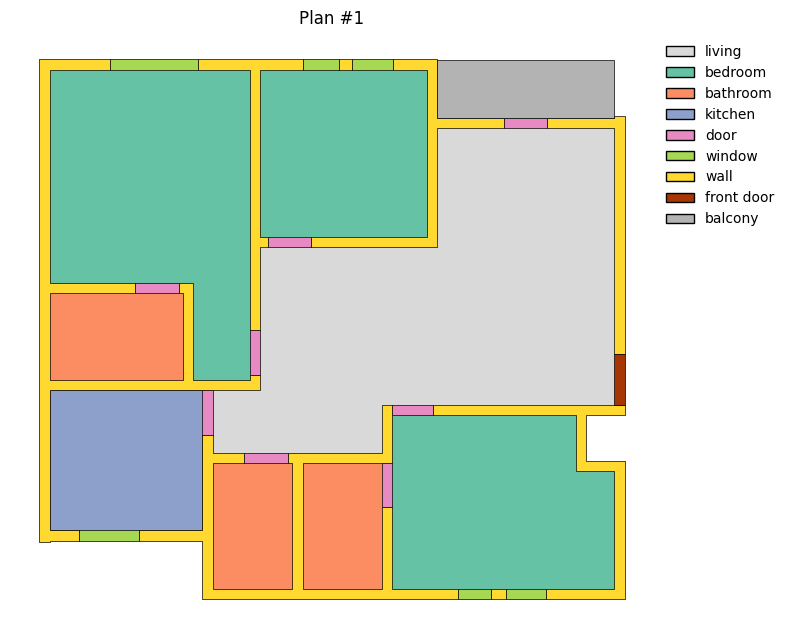

Total components found (excl. background): 9
  [skip (outside)] comp 1: area=  43837, bbox=(4,4,131,335)
  [skip (outside)] comp 2: area=  36005, bbox=(414,4,102,353)
  [KEEP] comp 3: area=  35103, bbox=(236,6,167,231)
  [KEEP] comp 4: area=   8788, bbox=(146,40,78,113)
  [KEEP] comp 5: area=   4281, bbox=(143,164,81,53)
  [KEEP] comp 6: area=   8654, bbox=(146,228,78,111)
  [skip (outside)] comp 7: area=  44638, bbox=(236,248,167,268)
  [skip (outside)] comp 8: area=  31979, bbox=(14,350,211,165)
  [skip (outside)] comp 9: area=  13477, bbox=(414,370,93,145)
Detected 4 rooms
  Room  1: bbox=(236, 6, 167, 231), centroid=(322, 130), area=35103
  Room  2: bbox=(146, 40, 78, 113), centroid=(184, 95), area=8788
  Room  3: bbox=(143, 164, 81, 53), centroid=(183, 190), area=4281
  Room  4: bbox=(146, 228, 78, 111), centroid=(184, 282), area=8654
<<< Graph >>>
Nodes:
  1: [[401, 6], [339, 6], [337, 40], [236, 40], [237, 236], [402, 234]]
  2: [[147, 40], [146, 151], [222, 152], [223, 40]]
  3

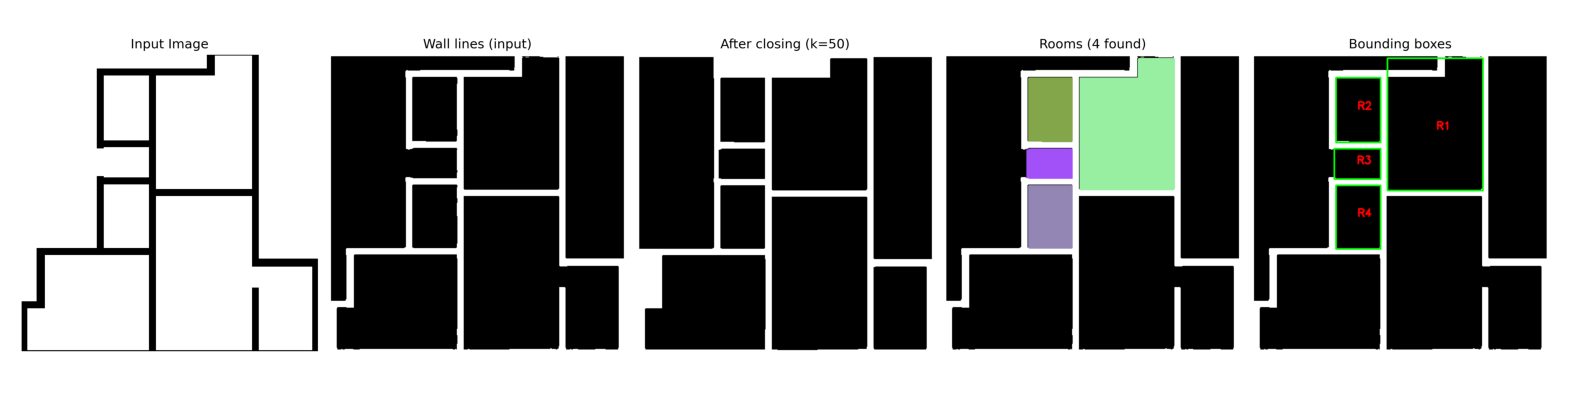

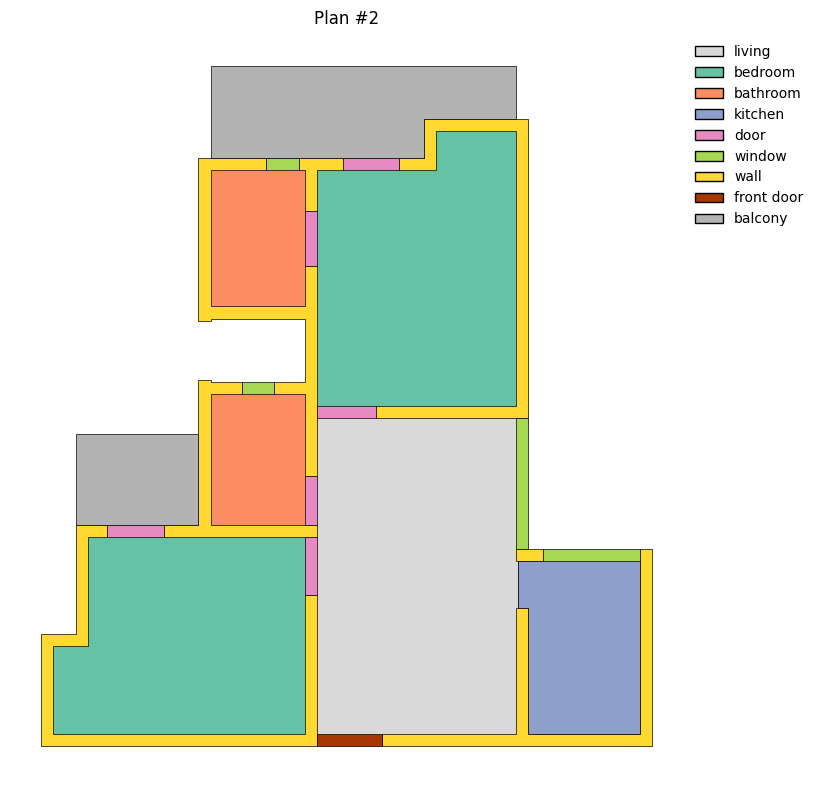

Total components found (excl. background): 9
  [skip (outside)] comp 1: area=  41046, bbox=(4,4,147,341)
  [skip (outside)] comp 2: area=  50279, bbox=(314,4,202,341)
  [KEEP] comp 3: area=  23353, bbox=(130,56,173,135)
  [KEEP] comp 4: area=   4756, bbox=(162,202,82,58)
  [KEEP] comp 5: area=  14249, bbox=(314,220,114,125)
  [KEEP] comp 6: area=  12958, bbox=(130,270,173,75)
  [KEEP] comp 7: area=  19463, bbox=(30,354,147,133)
  [skip (outside)] comp 8: area=  31360, bbox=(254,354,262,133)
  [KEEP] comp 9: area=   5045, bbox=(186,400,58,87)
Detected 6 rooms
  Room  1: bbox=(130, 56, 173, 135), centroid=(216, 123), area=23353
  Room  2: bbox=(162, 202, 82, 58), centroid=(202, 230), area=4756
  Room  3: bbox=(314, 220, 114, 125), centroid=(370, 281), area=14249
  Room  4: bbox=(130, 270, 173, 75), centroid=(215, 306), area=12958
  Room  5: bbox=(30, 354, 147, 133), centroid=(102, 420), area=19463
  Room  6: bbox=(186, 400, 58, 87), centroid=(214, 442), area=5045
<<< Graph >>>
Nodes:
  1

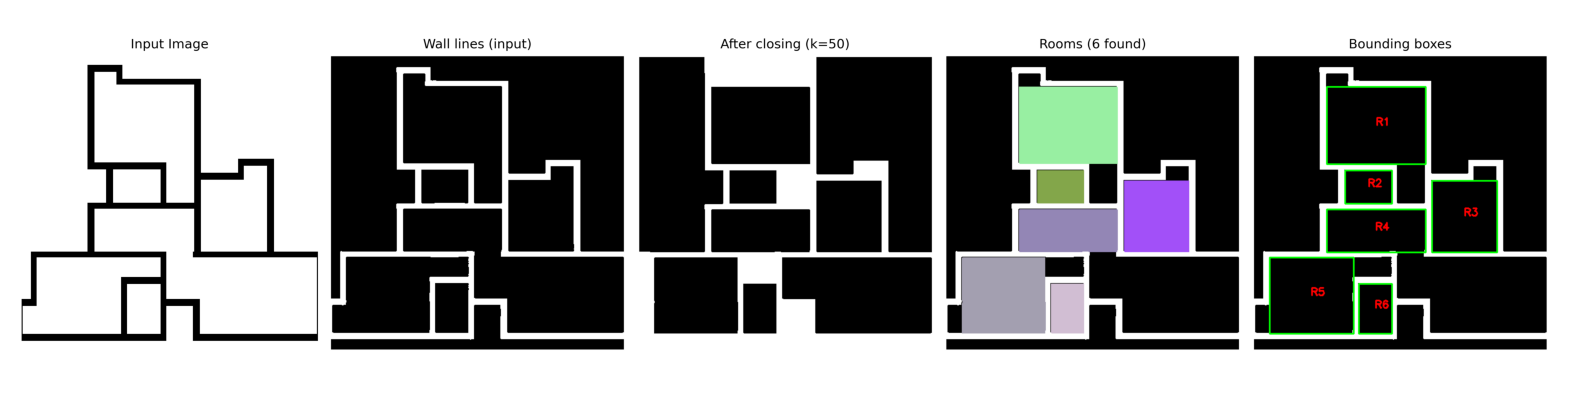

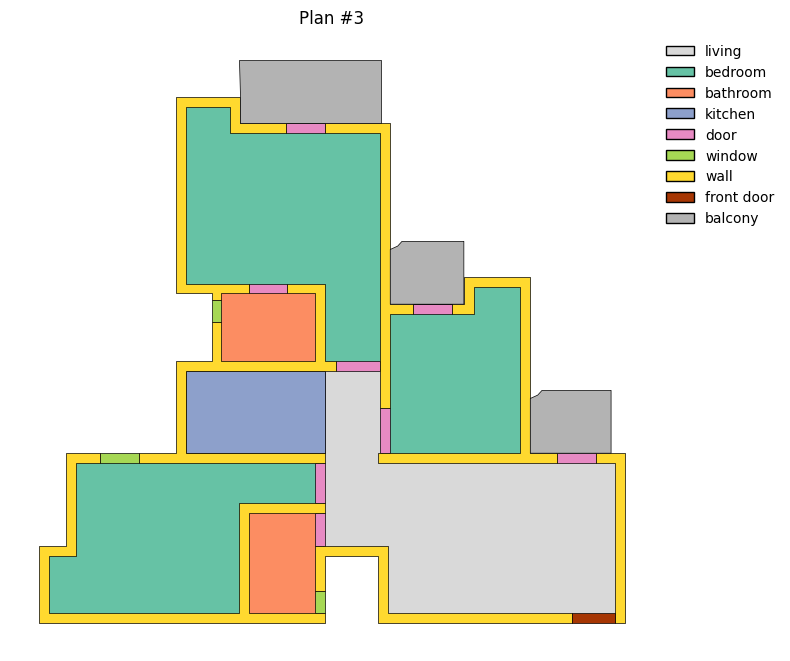

Total components found (excl. background): 8
  [skip (outside)] comp 1: area=  75982, bbox=(4,4,512,287)
  [skip (outside)] comp 2: area=  24916, bbox=(318,90,198,135)
  [KEEP] comp 3: area=   2704, bbox=(254,104,52,52)
  [KEEP] comp 4: area=  46596, bbox=(6,166,349,257)
  [KEEP] comp 5: area=   3240, bbox=(430,236,60,54)
  [KEEP] comp 6: area=  16601, bbox=(296,300,135,123)
  [skip (outside)] comp 7: area=   6911, bbox=(440,300,76,97)
  [skip (outside)] comp 8: area=  46857, bbox=(4,318,512,198)
Detected 4 rooms
  Room  1: bbox=(254, 104, 52, 52), centroid=(279, 129), area=2704
  Room  2: bbox=(6, 166, 349, 257), centroid=(172, 304), area=46596
  Room  3: bbox=(430, 236, 60, 54), centroid=(459, 262), area=3240
  Room  4: bbox=(296, 300, 135, 123), centroid=(362, 360), area=16601
<<< Graph >>>
Nodes:
  1: [[254, 104], [254, 155], [305, 155], [305, 104]]
  2: [[354, 237], [296, 235], [305, 166], [171, 166], [170, 299], [6, 300], [6, 421], [211, 421], [211, 309], [354, 290]]
  3: [[430, 

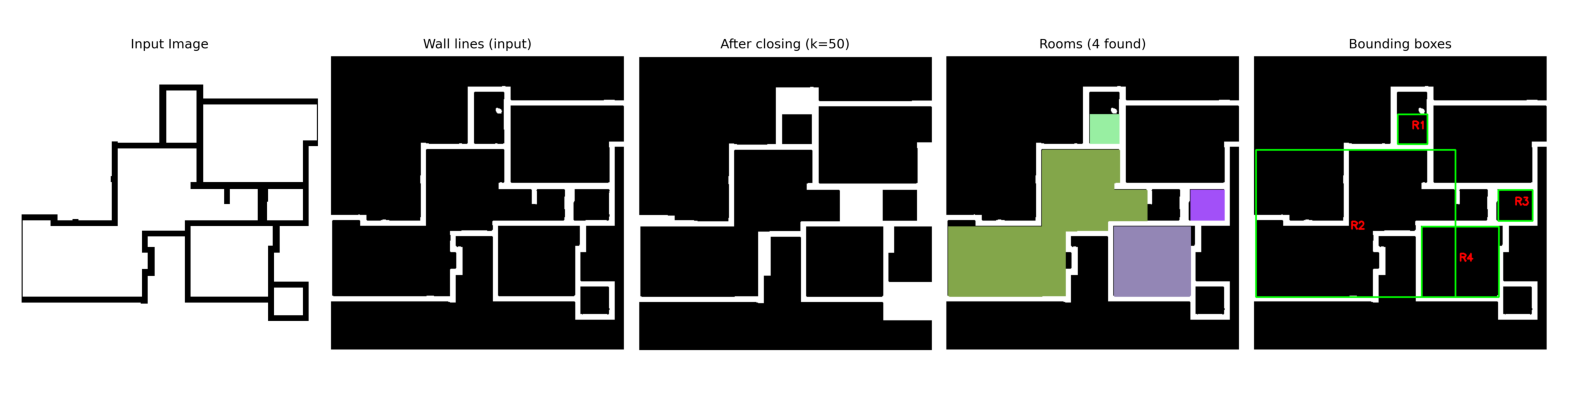

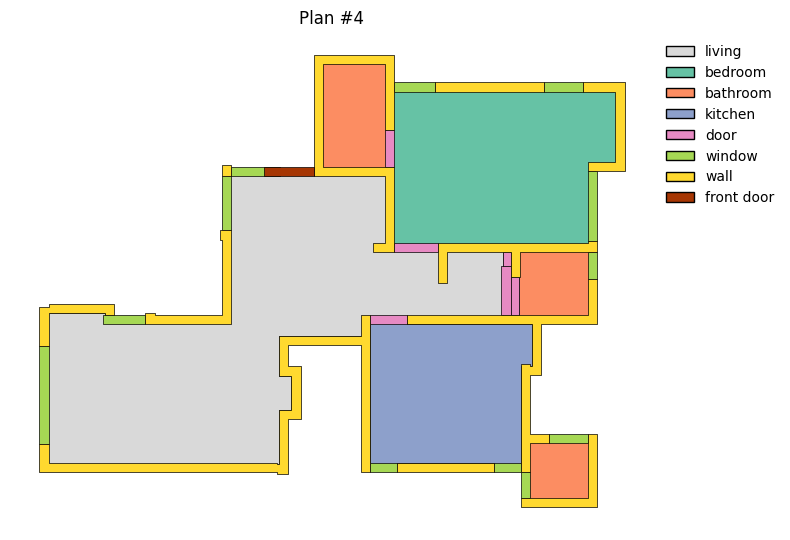

Total components found (excl. background): 8
  [skip (outside)] comp 1: area=  19783, bbox=(4,4,64,310)
  [skip (outside)] comp 2: area=  48376, bbox=(252,4,264,278)
  [KEEP] comp 3: area=  16854, bbox=(80,22,161,115)
  [KEEP] comp 4: area=  60053, bbox=(80,110,296,261)
  [skip (outside)] comp 5: area=  28911, bbox=(348,294,168,180)
  [KEEP] comp 6: area=  29423, bbox=(6,326,171,173)
  [KEEP] comp 7: area=   8067, bbox=(186,382,69,117)
  [KEEP] comp 8: area=   8119, bbox=(266,382,70,116)
Detected 5 rooms
  Room  1: bbox=(80, 22, 161, 115), centroid=(154, 74), area=16854
  Room  2: bbox=(80, 110, 296, 261), centroid=(233, 226), area=60053
  Room  3: bbox=(6, 326, 171, 173), centroid=(90, 411), area=29423
  Room  4: bbox=(186, 382, 69, 117), centroid=(219, 439), area=8067
  Room  5: bbox=(266, 382, 70, 116), centroid=(300, 439), area=8119
<<< Graph >>>
Nodes:
  1: [[80, 23], [81, 136], [181, 136], [183, 108], [239, 108], [239, 22]]
  2: [[375, 110], [194, 111], [193, 148], [80, 148], [80

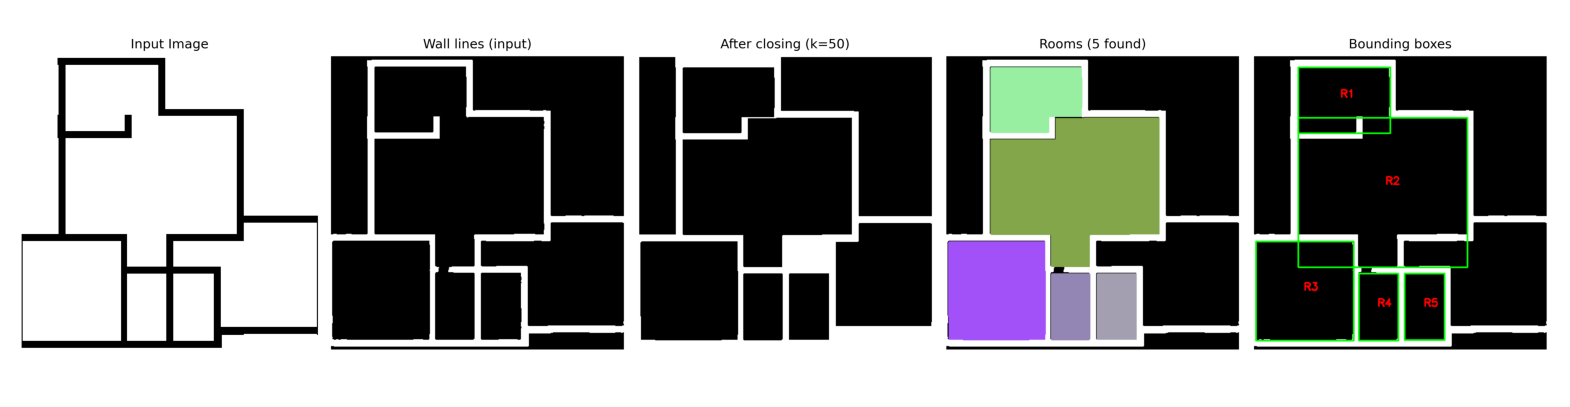

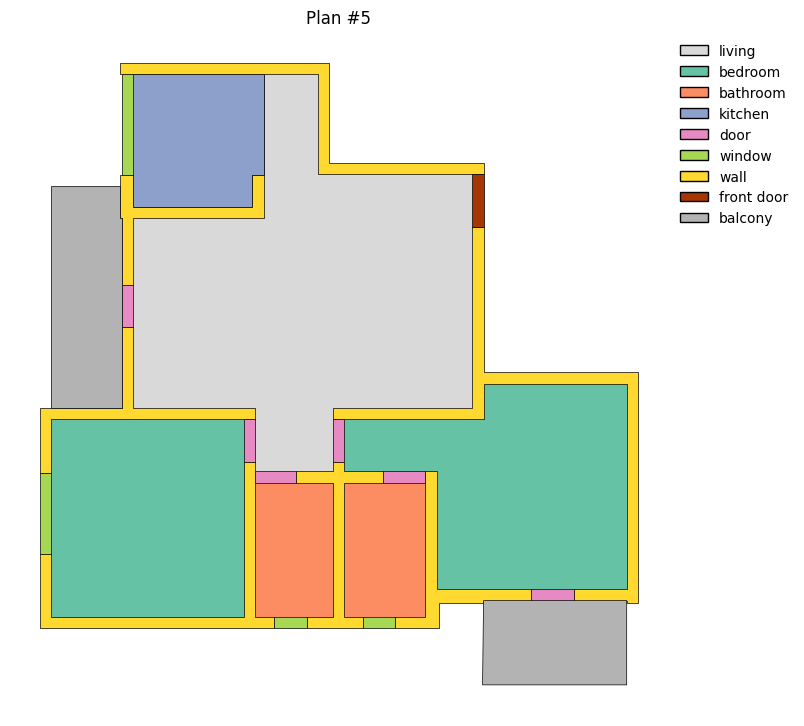

Total components found (excl. background): 9
  [skip (outside)] comp 1: area=  52725, bbox=(4,4,342,219)
  [KEEP] comp 2: area=  35571, bbox=(356,6,149,239)
  [KEEP] comp 3: area=  17413, bbox=(214,92,133,131)
  [KEEP] comp 4: area=  27114, bbox=(16,232,175,173)
  [KEEP] comp 5: area=  13263, bbox=(276,232,77,173)
  [KEEP] comp 6: area=   5855, bbox=(412,254,93,63)
  [KEEP] comp 7: area=   6012, bbox=(202,286,62,97)
  [skip (outside)] comp 8: area=  24676, bbox=(362,328,143,187)
  [skip (outside)] comp 9: area=  36363, bbox=(4,392,349,124)
Detected 6 rooms
  Room  1: bbox=(356, 6, 149, 239), centroid=(429, 124), area=35571
  Room  2: bbox=(214, 92, 133, 131), centroid=(279, 156), area=17413
  Room  3: bbox=(16, 232, 175, 173), centroid=(111, 321), area=27114
  Room  4: bbox=(276, 232, 77, 173), centroid=(313, 318), area=13263
  Room  5: bbox=(412, 254, 93, 63), centroid=(458, 285), area=5855
  Room  6: bbox=(202, 286, 62, 97), centroid=(232, 334), area=6012
<<< Graph >>>
Nodes:
  1: [[

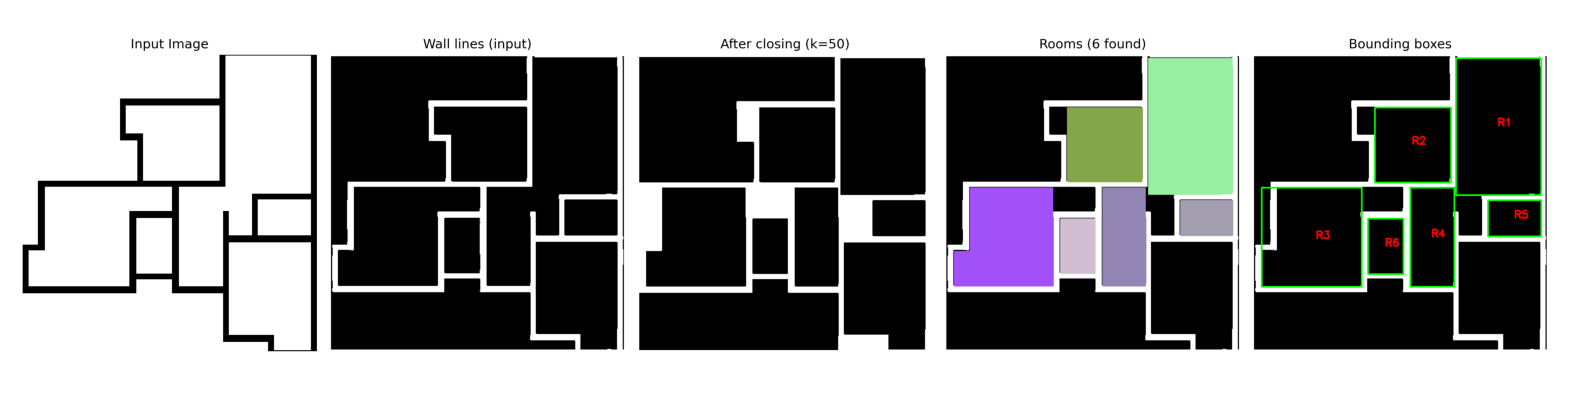

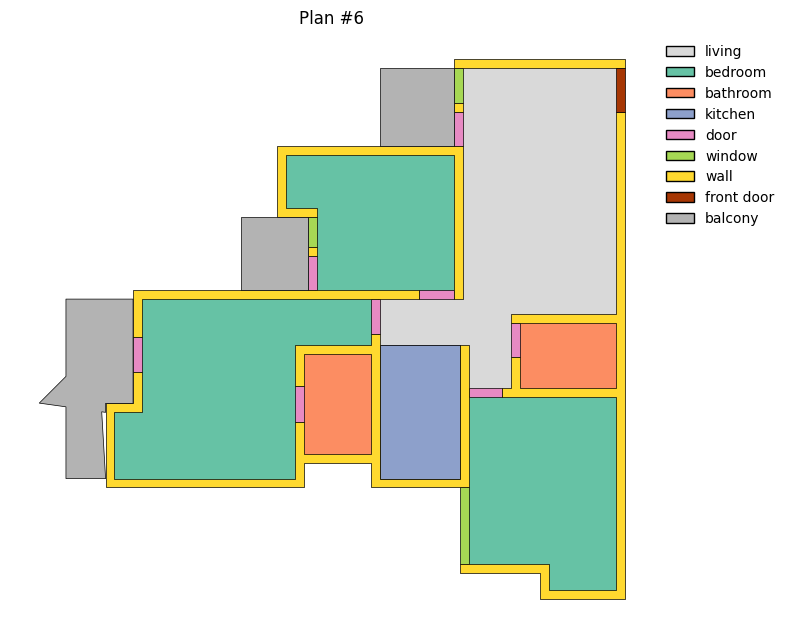

Total components found (excl. background): 9
  [skip (outside)] comp 1: area=  13120, bbox=(354,4,162,81)
  [KEEP] comp 2: area=  27383, bbox=(190,12,153,179)
  [KEEP] comp 3: area=  33385, bbox=(6,42,173,193)
  [skip (outside)] comp 4: area=  70021, bbox=(154,96,362,291)
  [skip (outside)] comp 5: area=   8748, bbox=(4,246,120,73)
  [KEEP] comp 6: area=  24552, bbox=(5,330,138,179)
  [skip (outside)] comp 7: area=  29229, bbox=(312,354,204,155)
  [KEEP] comp 8: area=   7655, bbox=(154,398,69,111)
  [KEEP] comp 9: area=   7628, bbox=(232,398,69,111)
Detected 5 rooms
  Room  1: bbox=(190, 12, 153, 179), centroid=(265, 100), area=27383
  Room  2: bbox=(6, 42, 173, 193), centroid=(92, 138), area=33385
  Room  3: bbox=(5, 330, 138, 179), centroid=(73, 418), area=24552
  Room  4: bbox=(154, 398, 69, 111), centroid=(188, 453), area=7655
  Room  5: bbox=(232, 398, 69, 111), centroid=(265, 453), area=7628
<<< Graph >>>
Nodes:
  1: [[190, 12], [190, 189], [341, 190], [342, 13]]
  2: [[7, 42], [

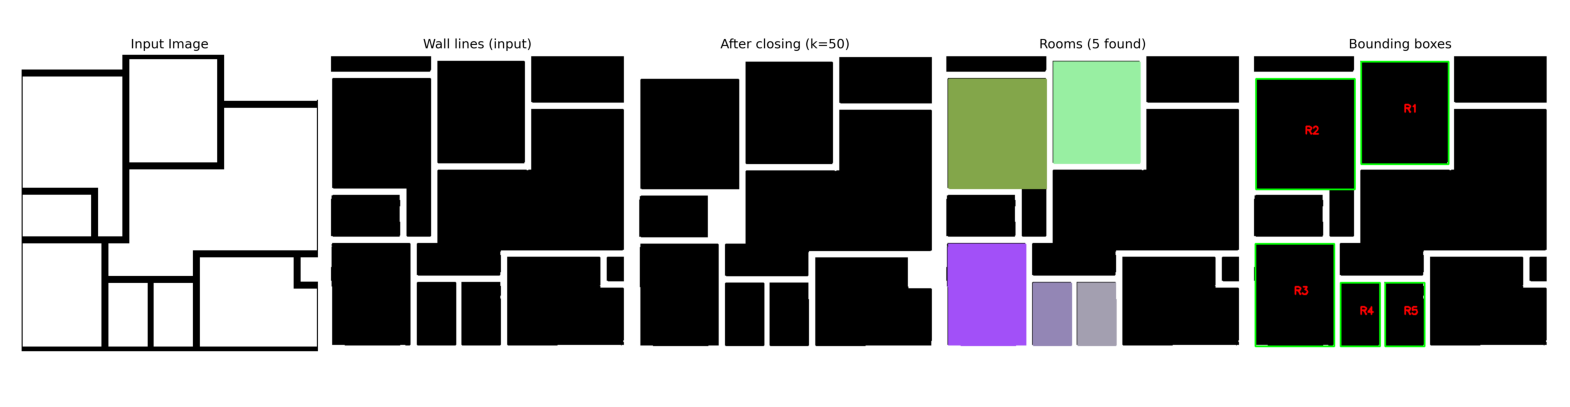

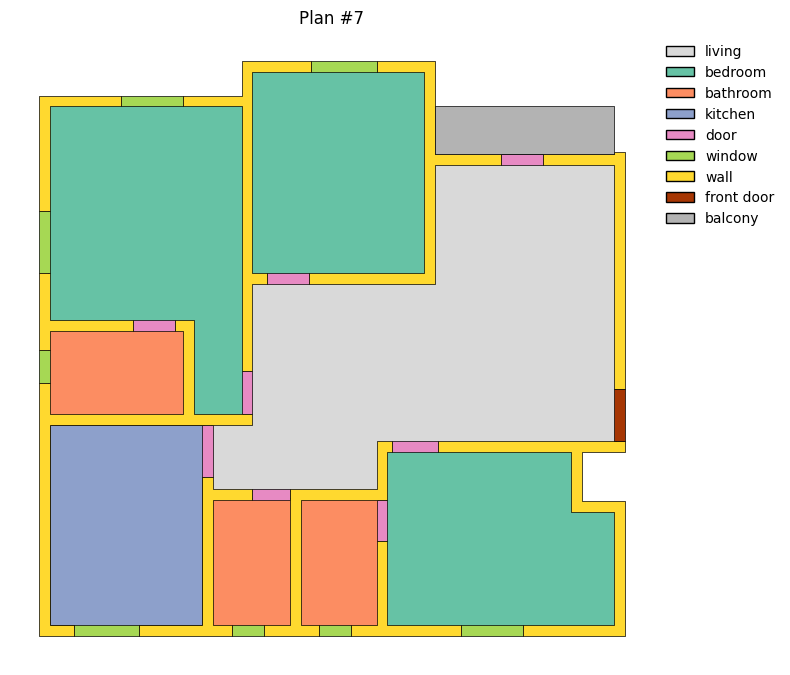

Total components found (excl. background): 2
  [skip (area)] comp 1: area= 141881, bbox=(4,4,512,512)
  [skip (outside)] comp 2: area=  99284, bbox=(170,4,346,287)
Detected 0 rooms
<<< Graph >>>
Nodes:
Edges:
Total components found (excl. background): 2
  [skip (area)] comp 1: area= 141881, bbox=(4,4,512,512)
  [skip (outside)] comp 2: area=  99284, bbox=(170,4,346,287)
Detected 0 rooms
{'error': 'No GT nodes or predicted rooms to compare.'}


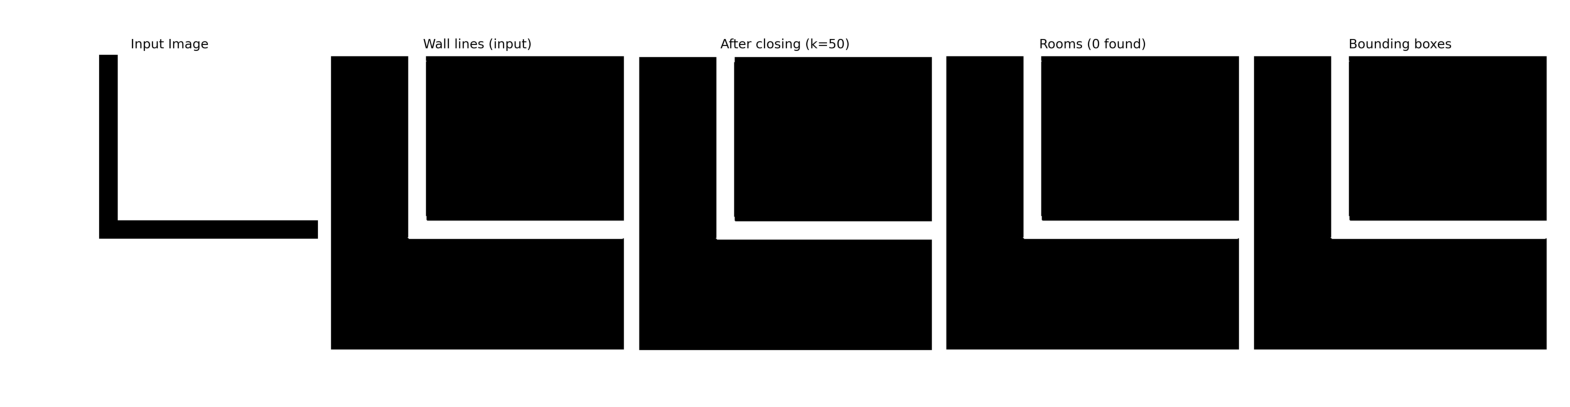

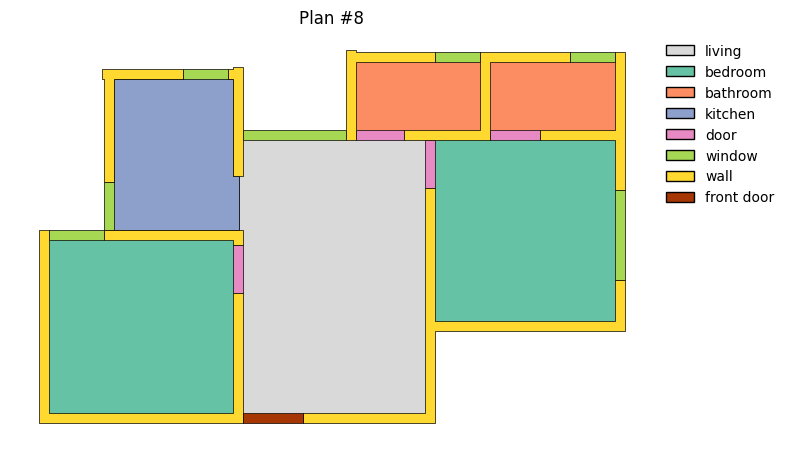

Total components found (excl. background): 8
  [skip (outside)] comp 1: area=  61846, bbox=(4,4,512,246)
  [KEEP] comp 2: area=  19841, bbox=(6,94,154,129)
  [KEEP] comp 3: area=  14781, bbox=(168,112,91,172)
  [skip (outside)] comp 4: area=  47032, bbox=(268,112,247,276)
  [KEEP] comp 5: area=   5130, bbox=(24,230,95,54)
  [KEEP] comp 6: area=   5879, bbox=(24,292,98,60)
  [KEEP] comp 7: area=  16980, bbox=(132,292,127,134)
  [skip (outside)] comp 8: area=  65582, bbox=(4,340,512,176)
Detected 5 rooms
  Room  1: bbox=(6, 94, 154, 129), centroid=(82, 158), area=19841
  Room  2: bbox=(168, 112, 91, 172), centroid=(215, 193), area=14781
  Room  3: bbox=(24, 230, 95, 54), centroid=(71, 256), area=5130
  Room  4: bbox=(24, 292, 98, 60), centroid=(72, 321), area=5879
  Room  5: bbox=(132, 292, 127, 134), centroid=(194, 358), area=16980
<<< Graph >>>
Nodes:
  1: [[7, 95], [6, 221], [159, 221], [159, 94]]
  2: [[168, 112], [168, 237], [187, 240], [187, 283], [258, 283], [257, 112]]
  3: [[24,

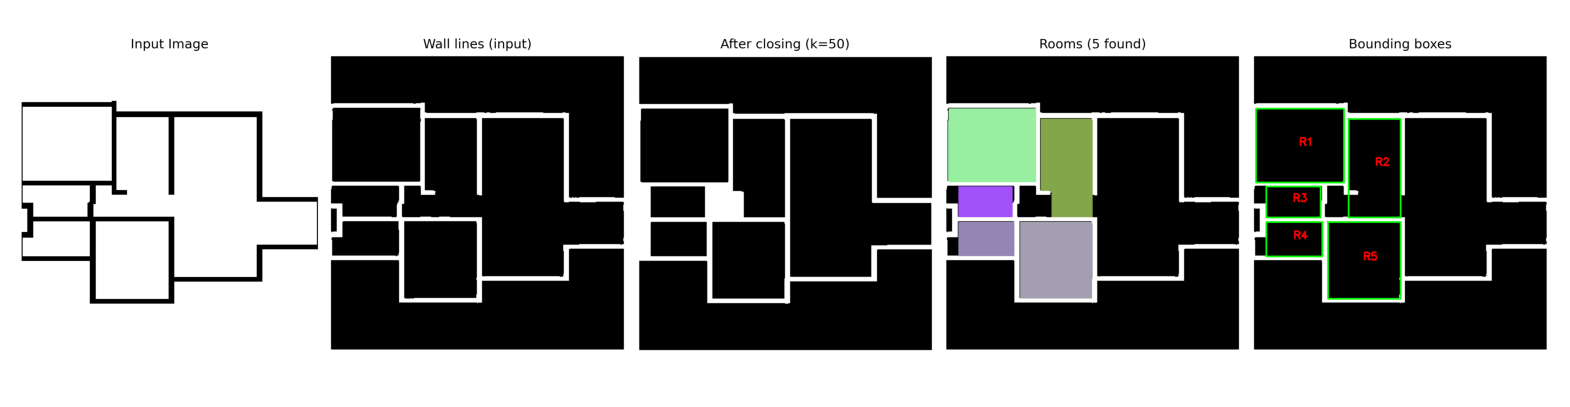

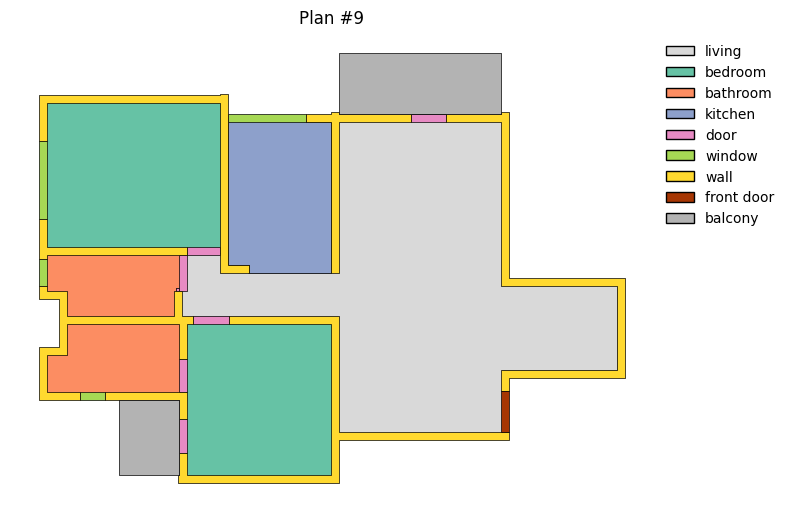

In [ ]:
for idx in range(0, 10):
    plan = plans[idx]

    SHAPE = (512, 512)

    img = get_2d_plan(plan, show=False)
    img_path = f'plans/plan_{idx}.png'
    cv2.imwrite(img_path, img)

    # pred_graph = build_graph(img_path)   # your existing function
    pred_graph = build_graph(img_path, border=3, kernel_size=50, iterations=1, min_room_area = 10, max_room_area=100000)

    img = cv2.imread('room_detection.png')
    # set fig size to 10x10 inches

    pred_wall = predict(img_path, show=False)  # your existing function
    rooms      = find_room_boundaries(img_path, pred_wall, border=3, kernel_size=50, iterations=1, min_room_area=10, max_room_area=100000)  # already returns rooms
    metrics    = validate_graph(plan, rooms, pred_graph, shape=(512, 512))
    print(metrics)

    plt.figure(figsize=(20, 20))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # plot the original plot_plan
    ax = plot_plan(plan, title=f'Plan #{idx}')
    plt.show()